# MindScan — Dataset 3 Split Study
## NCI H9DAI · MSc Artificial Intelligence 2026
### RQ: Does Training Data Volume Affect Model Performance When Distribution Is Held Constant?

| Split | Rows | Suicide | Non-Suicide |
|-------|------|---------|-------------|
| **D3-Full** | 232,074 | 116,037 (50%) | 116,037 (50%) |
| **D3-H1** | 116,037 | 58,071 (50%) | 57,966 (50%) |
| **D3-H2** | 116,037 | 57,966 (50%) | 58,071 (50%) |

**Models:** Logistic Regression · SVM (LinearSVC) · XGBoost · XLM-RoBERTa
**Methodology:** CRISP-DM (Chapman et al., 2000)


---
## Section 0 — Setup
Run every time you open the notebook. Requires T4 GPU for XLM-RoBERTa.

In [1]:
# 0.1 GPU check
import subprocess
r = subprocess.run(['nvidia-smi','--query-gpu=name,memory.total','--format=csv,noheader'],
                  capture_output=True, text=True)
if r.returncode == 0:
    print("GPU:", r.stdout.strip())
else:
    print("WARNING: No GPU. Go to Runtime > Change runtime type > T4 GPU")


GPU: Tesla T4, 15360 MiB


In [2]:
# 0.2 Install dependencies
!pip install -q transformers datasets accelerate scikit-learn xgboost
!pip install -q matplotlib seaborn wordcloud scipy imbalanced-learn
print("Done.")


Done.


In [3]:
# 0.3 Imports
import pandas as pd
import numpy as np
import re, string, os, joblib, warnings, json
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter
from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import (accuracy_score, f1_score, cohen_kappa_score,
                              classification_report, confusion_matrix, roc_auc_score)
from xgboost import XGBClassifier

import torch
from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                           TrainingArguments, Trainer)
from datasets import Dataset as HFDataset

warnings.filterwarnings('ignore')
RANDOM_STATE = 42
plt.rcParams['figure.dpi'] = 120

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"PyTorch {torch.__version__} | CUDA: {torch.cuda.is_available()} | Device: {DEVICE}")


PyTorch 2.10.0+cu128 | CUDA: True | Device: cuda


In [4]:
# 0.4 Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')
DRIVE_DIR = '/content/drive/MyDrive/MindScan_SplitStudy'
os.makedirs(DRIVE_DIR, exist_ok=True)
print(f"Output directory: {DRIVE_DIR}")


Mounted at /content/drive
Output directory: /content/drive/MyDrive/MindScan_SplitStudy


In [5]:
# 0.5 Upload CSV files
# Upload DA_DB_3.csv, DA_DB_3_H1.csv, DA_DB_3_H2.csv
from google.colab import files
print("Please upload: DA_DB_3.csv  |  DA_DB_3_H1.csv  |  DA_DB_3_H2.csv")
uploaded = files.upload()
print("Uploaded:", list(uploaded.keys()))


Please upload: DA_DB_3.csv  |  DA_DB_3_H1.csv  |  DA_DB_3_H2.csv


Saving DA_DB_3_H1.csv to DA_DB_3_H1.csv
Saving DA_DB_3_H2.csv to DA_DB_3_H2.csv
Saving DA_DB_3.csv to DA_DB_3.csv
Uploaded: ['DA_DB_3_H1.csv', 'DA_DB_3_H2.csv', 'DA_DB_3.csv']


---
## CRISP-DM Stage 1 — Business Understanding

### Background
Suicide risk detection in online text has significant public health implications. Our original MindScan experiment trained XLM-RoBERTa on 50,000 Reddit posts (25k/class), achieving **F1=0.9810**.

A key operational question: **how sensitive is performance to training set size?** Labelling clinical text is expensive. If 50% of the data achieves equivalent performance to 100%, the labelling budget can be halved.

### Research Question
> *Does training data volume affect suicide risk classification performance when class distribution and text characteristics are held constant?*

### Hypotheses
- **H1 (Classical models):** Full dataset will outperform halves by a meaningful margin (>0.5% F1), as bag-of-words models continue to benefit from vocabulary coverage
- **H2 (XLM-RoBERTa):** Transformer will show smaller sensitivity to data volume — pre-training on 2.5TB of multilingual text provides a strong prior that reduces dependency on fine-tuning volume
- **H3 (Split consistency):** H1 and H2 will produce near-identical scores, confirming the dataset is uniformly shuffled with no systematic ordering bias

### Success Criteria
| Criterion | Threshold |
|-----------|-----------|
| Meaningful volume effect | Gap > 0.5% Macro F1 between Full and average of halves |
| Split consistency | |H1 − H2| < 0.3% F1 |
| Transformer advantage | XLM-RoBERTa F1 > best classical by > 1% on Full split |


---
## CRISP-DM Stage 2 — Data Understanding & Exploratory Data Analysis

In [6]:
# 2.1 Load all three splits
df_full = pd.read_csv('DA_DB_3.csv')
df_h1   = pd.read_csv('DA_DB_3_H1.csv')
df_h2   = pd.read_csv('DA_DB_3_H2.csv')

# Standardise column names
for df in [df_full, df_h1, df_h2]:
    df.rename(columns={c: c.lower().strip() for c in df.columns}, inplace=True)
    drop_cols = [c for c in df.columns if c.startswith('unnamed')]
    df.drop(columns=drop_cols, inplace=True)

DATASETS = {'D3-Full': df_full, 'D3-H1': df_h1, 'D3-H2': df_h2}

print("=" * 55)
for name, df in DATASETS.items():
    counts = df['class'].value_counts()
    print(f"\n{name} ({len(df):,} rows):")
    for label, cnt in counts.items():
        print(f"  {label:<15}: {cnt:,}  ({cnt/len(df)*100:.2f}%)")



D3-Full (232,074 rows):
  suicide        : 116,037  (50.00%)
  non-suicide    : 116,037  (50.00%)

D3-H1 (116,037 rows):
  suicide        : 58,071  (50.05%)
  non-suicide    : 57,966  (49.95%)

D3-H2 (116,037 rows):
  non-suicide    : 58,071  (50.05%)
  suicide        : 57,966  (49.95%)


In [7]:
# 2.2 Data quality checks
print("=" * 55)
print("  NULL / DUPLICATE / EMPTY CHECK")
print("=" * 55)
for name, df in DATASETS.items():
    nulls  = df.isnull().sum().sum()
    dups   = df.duplicated(subset=['text']).sum()
    empty  = (df['text'].str.strip() == '').sum()
    print(f"{name}: nulls={nulls}  text_duplicates={dups}  empty={empty}")


  NULL / DUPLICATE / EMPTY CHECK
D3-Full: nulls=0  text_duplicates=0  empty=0
D3-H1: nulls=0  text_duplicates=0  empty=0
D3-H2: nulls=0  text_duplicates=0  empty=0


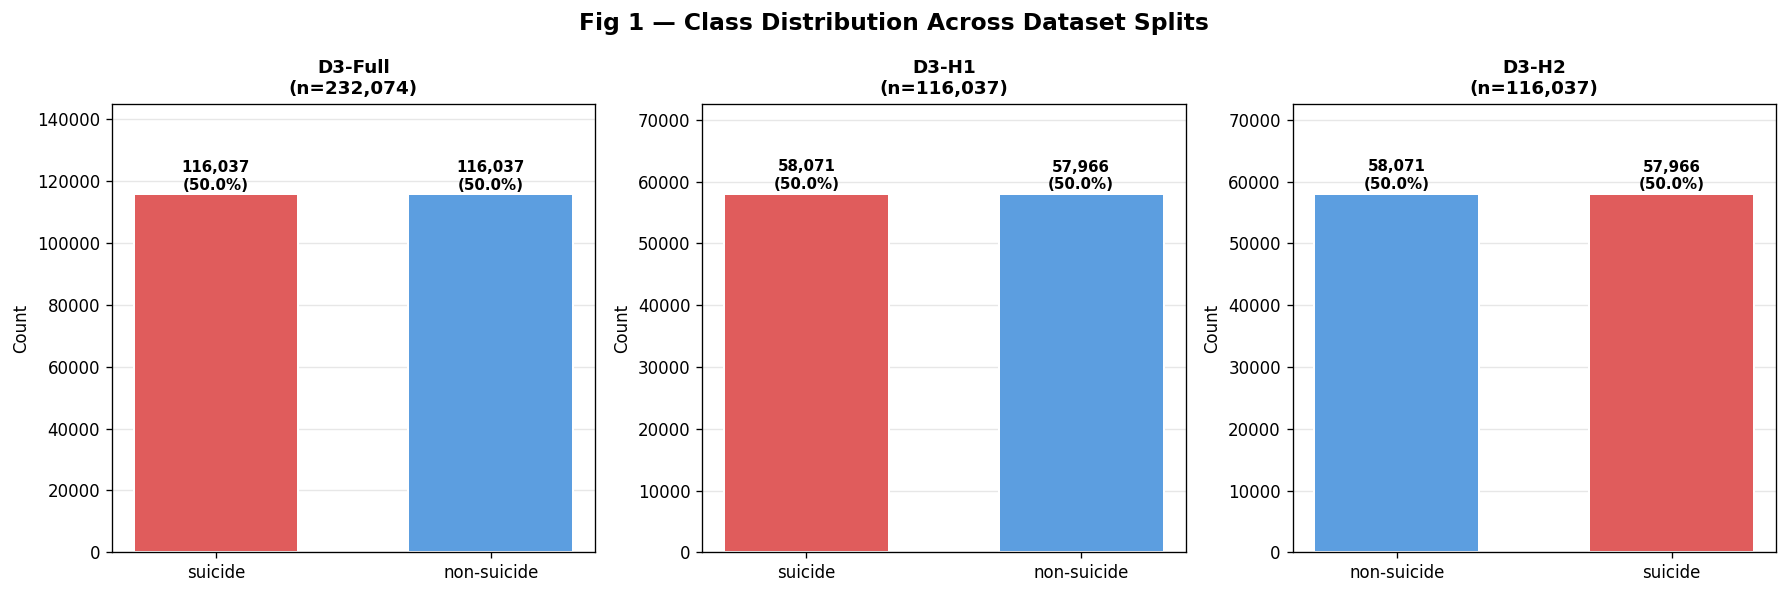

In [8]:
# 2.3 EDA Fig 1 — Class Distribution Across Splits
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Fig 1 — Class Distribution Across Dataset Splits', fontsize=14, fontweight='bold')
colors = {'suicide': '#e05c5c', 'non-suicide': '#5c9ee0'}

for ax, (name, df) in zip(axes, DATASETS.items()):
    counts = df['class'].value_counts()
    bars = ax.bar(counts.index, counts.values,
                  color=[colors.get(l,'#888') for l in counts.index],
                  edgecolor='white', linewidth=1.2, width=0.6)
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+300,
                f"{val:,}\n({val/len(df)*100:.1f}%)",
                ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax.set_title(f"{name}\n(n={len(df):,})", fontsize=11, fontweight='bold')
    ax.set_ylabel('Count'); ax.set_ylim(0, max(counts.values)*1.25)
    ax.grid(axis='y', alpha=0.3); ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig(os.path.join(DRIVE_DIR, 'fig1_class_distribution.png'), bbox_inches='tight')
plt.show()


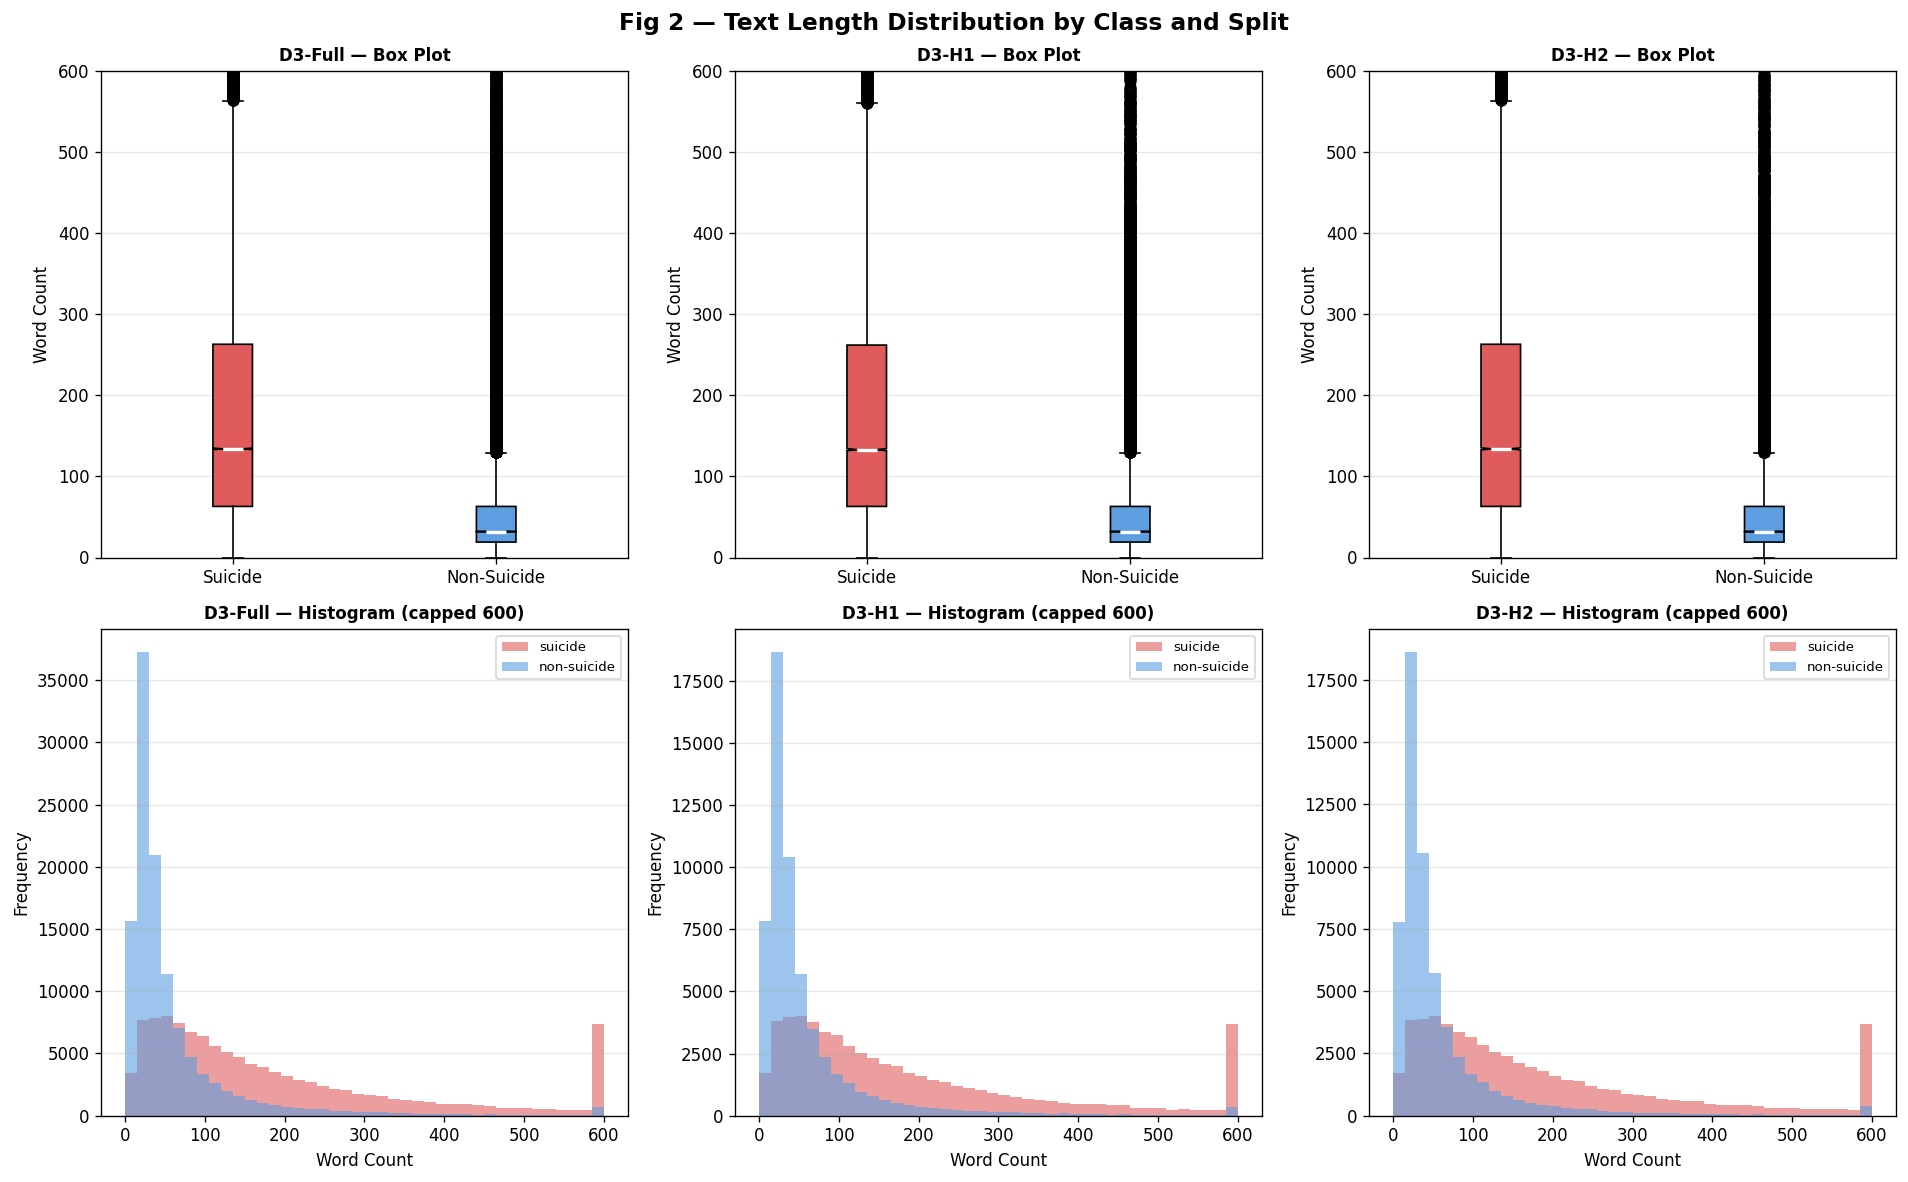


Text Length Summary:
Split        Class                Mean   Median      Std    Max
------------------------------------------------------------
D3-Full      suicide             212.1      134    264.4   9685
D3-Full      non-suicide          63.1       32    138.4   8221
D3-H1        suicide             211.8      133    264.6   7481
D3-H1        non-suicide          63.3       32    143.6   7758
D3-H2        suicide             212.4      134    264.2   9685
D3-H2        non-suicide          62.9       32    133.0   8221


In [9]:
# 2.4 Text Length Analysis
def word_count(text):
    return len(re.findall(r'\w+', str(text)))

for name, df in DATASETS.items():
    df['word_count'] = df['text'].apply(word_count)

# EDA Fig 2 — Text Length by Class and Split
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Fig 2 — Text Length Distribution by Class and Split', fontsize=14, fontweight='bold')

for col, (name, df) in enumerate(DATASETS.items()):
    # Box plot row
    data_bp = [df[df['class']==lbl]['word_count'].values for lbl in ['suicide','non-suicide']]
    bp = axes[0,col].boxplot(data_bp, labels=['Suicide','Non-Suicide'],
                              patch_artist=True, notch=True,
                              medianprops={'color':'white','linewidth':2})
    bp['boxes'][0].set_facecolor('#e05c5c')
    bp['boxes'][1].set_facecolor('#5c9ee0')
    axes[0,col].set_title(f"{name} — Box Plot", fontsize=10, fontweight='bold')
    axes[0,col].set_ylabel('Word Count'); axes[0,col].set_ylim(0, 600)
    axes[0,col].grid(axis='y', alpha=0.3)

    # Histogram row
    for lbl, col_hex in [('suicide','#e05c5c'),('non-suicide','#5c9ee0')]:
        subset = df[df['class']==lbl]['word_count'].clip(0,600)
        axes[1,col].hist(subset, bins=40, alpha=0.6, color=col_hex, label=lbl, edgecolor='none')
    axes[1,col].set_title(f"{name} — Histogram (capped 600)", fontsize=10, fontweight='bold')
    axes[1,col].set_xlabel('Word Count'); axes[1,col].set_ylabel('Frequency')
    axes[1,col].legend(fontsize=8); axes[1,col].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(DRIVE_DIR, 'fig2_text_length.png'), bbox_inches='tight')
plt.show()

print("\nText Length Summary:")
print(f"{'Split':<12} {'Class':<16} {'Mean':>8} {'Median':>8} {'Std':>8} {'Max':>6}")
print("-"*60)
for name, df in DATASETS.items():
    for lbl in ['suicide','non-suicide']:
        wc = df[df['class']==lbl]['word_count']
        print(f"{name:<12} {lbl:<16} {wc.mean():>8.1f} {wc.median():>8.0f} {wc.std():>8.1f} {wc.max():>6}")


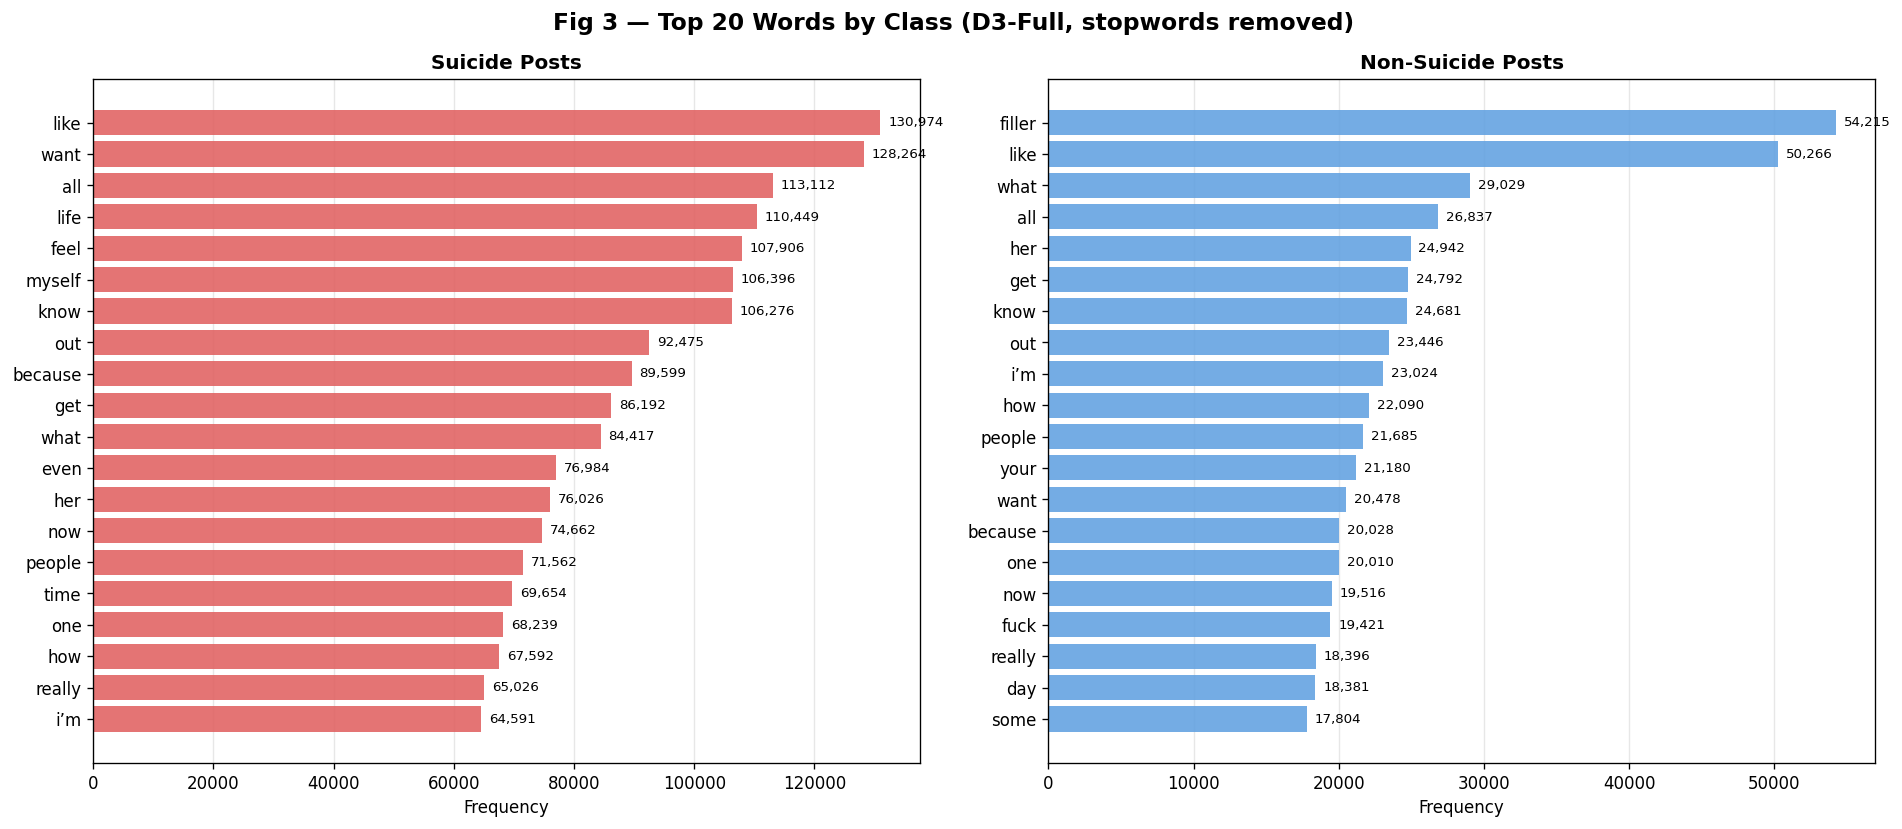

In [10]:
# 2.5 Word Frequency Analysis
STOPWORDS = set(['the','a','an','and','or','but','in','on','at','to','for','of','is',
                 'it','this','that','was','are','be','as','i','my','me','we','you',
                 'he','she','they','have','has','had','do','did','will','would','can',
                 'could','just','not','with','from','so','if','about','when','been',
                 'also','its','up','im','ive','dont','cant','wont','its','there'])

def clean_for_freq(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = text.translate(str.maketrans('','',string.punctuation))
    return text

def top_words(texts, n=20):
    all_words = []
    for t in texts:
        all_words.extend([w for w in clean_for_freq(t).split()
                          if w not in STOPWORDS and len(w) > 2])
    return Counter(all_words).most_common(n)

df = df_full.copy()
suicide_words     = top_words(df[df['class']=='suicide']['text'])
non_suicide_words = top_words(df[df['class']=='non-suicide']['text'])

# Fig 3 — Top Word Frequencies
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Fig 3 — Top 20 Words by Class (D3-Full, stopwords removed)',
             fontsize=14, fontweight='bold')

for ax, (title, word_counts, color) in zip(axes, [
    ('Suicide Posts',     suicide_words,     '#e05c5c'),
    ('Non-Suicide Posts', non_suicide_words, '#5c9ee0')
]):
    words, counts = zip(*word_counts)
    y_pos = range(len(words))
    bars = ax.barh(y_pos, counts, color=color, alpha=0.85, edgecolor='none')
    ax.set_yticks(y_pos); ax.set_yticklabels(words, fontsize=10)
    ax.invert_yaxis()
    ax.set_xlabel('Frequency')
    ax.set_title(title, fontsize=12, fontweight='bold')
    for bar, cnt in zip(bars, counts):
        ax.text(bar.get_width()+max(counts)*0.01, bar.get_y()+bar.get_height()/2,
                f"{cnt:,}", va='center', fontsize=8)
    ax.grid(axis='x', alpha=0.3); ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig(os.path.join(DRIVE_DIR, 'fig3_word_frequency.png'), bbox_inches='tight')
plt.show()


In [11]:
# 2.6 Statistical Validation — KS Test + Transition Rate
print("=" * 65)
print("  KS TEST: Are H1 and H2 from the same distribution?")
print("=" * 65)
print("(p > 0.05 = cannot reject same-distribution hypothesis)")
print()

for lbl in ['suicide','non-suicide']:
    h1_wc   = df_h1[df_h1['class']==lbl]['word_count'].values
    h2_wc   = df_h2[df_h2['class']==lbl]['word_count'].values
    full_wc = df_full[df_full['class']==lbl]['word_count'].values

    ks12, p12   = stats.ks_2samp(h1_wc, h2_wc)
    ks_fh1, pfh1 = stats.ks_2samp(full_wc, h1_wc)
    ks_fh2, pfh2 = stats.ks_2samp(full_wc, h2_wc)

    print(f"Class: {lbl}")
    print(f"  KS(H1 vs H2)   : stat={ks12:.4f}   p={p12:.4f}   {'SAME' if p12>0.05 else 'DIFFERENT'}")
    print(f"  KS(Full vs H1) : stat={ks_fh1:.4f}  p={pfh1:.4f}   {'SAME' if pfh1>0.05 else 'DIFFERENT'}")
    print(f"  KS(Full vs H2) : stat={ks_fh2:.4f}  p={pfh2:.4f}   {'SAME' if pfh2>0.05 else 'DIFFERENT'}")
    print()

print("=" * 65)
print("  SHUFFLE VALIDATION (50% transitions = perfectly random)")
print("=" * 65)
for name, df in DATASETS.items():
    labels = df['class'].tolist()
    transitions = sum(1 for i in range(1,len(labels)) if labels[i]!=labels[i-1])
    rate = transitions/(len(labels)-1)*100
    print(f"  {name}: {transitions:,}/{len(labels)-1:,} transitions ({rate:.1f}%)")


  KS TEST: Are H1 and H2 from the same distribution?
(p > 0.05 = cannot reject same-distribution hypothesis)

Class: suicide
  KS(H1 vs H2)   : stat=0.0049   p=0.4967   SAME
  KS(Full vs H1) : stat=0.0024  p=0.9758   SAME
  KS(Full vs H2) : stat=0.0024  p=0.9755   SAME

Class: non-suicide
  KS(H1 vs H2)   : stat=0.0037   p=0.8125   SAME
  KS(Full vs H1) : stat=0.0019  p=0.9992   SAME
  KS(Full vs H2) : stat=0.0019  p=0.9993   SAME

  SHUFFLE VALIDATION (50% transitions = perfectly random)
  D3-Full: 116,367/232,073 transitions (50.1%)
  D3-H1: 58,202/116,036 transitions (50.2%)
  D3-H2: 58,165/116,036 transitions (50.1%)


Vocabulary Summary:
  Split       Class  Unique    Total  Density
D3-Full     suicide  158943 16935124     0.94
D3-Full non-suicide  121209  5196728     2.33
  D3-H1     suicide  103402  8465409     1.22
  D3-H1 non-suicide   81817  2608185     3.14
  D3-H2     suicide  102663  8469715     1.21
  D3-H2 non-suicide   75405  2588543     2.91


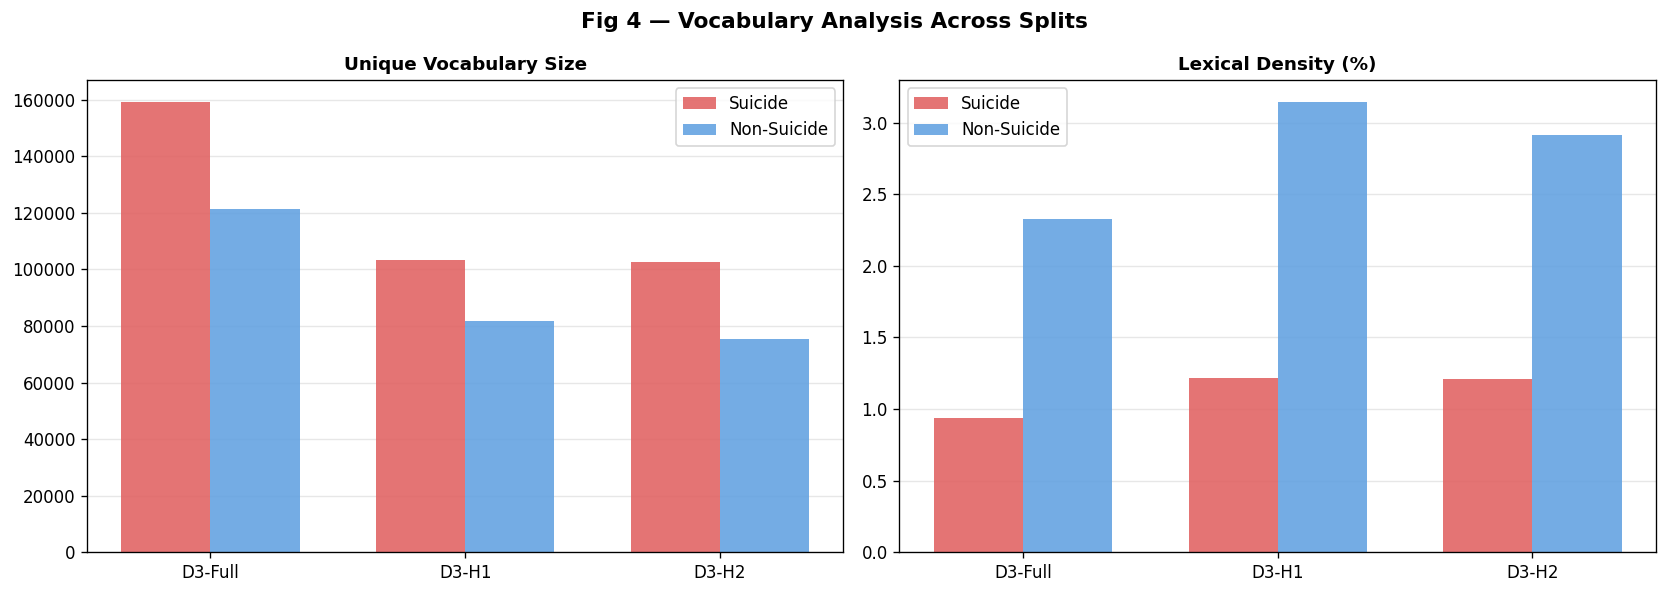

In [12]:
# 2.7 EDA Fig 4 — Vocabulary Analysis
vocab_data = []
for name, df in DATASETS.items():
    for lbl in ['suicide','non-suicide']:
        texts = df[df['class']==lbl]['text'].apply(clean_for_freq)
        all_words = []
        for t in texts:
            all_words.extend([w for w in t.split() if len(w)>2])
        unique = len(set(all_words))
        total  = len(all_words)
        vocab_data.append({'Split':name, 'Class':lbl,
                           'Unique':unique, 'Total':total,
                           'Density':round(unique/total*100,2)})

vocab_df = pd.DataFrame(vocab_data)
print("Vocabulary Summary:")
print(vocab_df.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Fig 4 — Vocabulary Analysis Across Splits', fontsize=13, fontweight='bold')
x = np.arange(3); w = 0.35
split_names = list(DATASETS.keys())

for ax, metric, title in [(axes[0],'Unique','Unique Vocabulary Size'),
                           (axes[1],'Density','Lexical Density (%)')]:
    sv  = [vocab_df[(vocab_df['Split']==s)&(vocab_df['Class']=='suicide')][metric].values[0]
           for s in split_names]
    nsv = [vocab_df[(vocab_df['Split']==s)&(vocab_df['Class']=='non-suicide')][metric].values[0]
           for s in split_names]
    ax.bar(x-w/2, sv,  w, label='Suicide',     color='#e05c5c', alpha=0.85)
    ax.bar(x+w/2, nsv, w, label='Non-Suicide', color='#5c9ee0', alpha=0.85)
    ax.set_xticks(x); ax.set_xticklabels(split_names)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.legend(); ax.grid(axis='y', alpha=0.3); ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig(os.path.join(DRIVE_DIR, 'fig4_vocabulary.png'), bbox_inches='tight')
plt.show()


---
## CRISP-DM Stage 3 — Data Preparation & Feature Engineering

### Preprocessing Pipeline
1. **Lowercase** — normalise case variation
2. **URL removal** — `http/https/www` patterns carry no semantic signal
3. **@mention removal** — Reddit handles are noise
4. **Punctuation removal** — reduces vocabulary fragmentation
5. **Whitespace normalisation** — clean tokenisation

### TF-IDF Design Choices
| Parameter | Value | Justification |
|-----------|-------|---------------|
| `max_features` | 60,000 | Matches original D3 experiment; captures rich Reddit vocabulary |
| `ngram_range` | (1, 2) | Bigrams capture key phrases: *"want to die"*, *"feeling hopeless"* |
| `min_df` | 2 | Removes hapax legomena that won't generalise |
| `sublinear_tf` | True | Log-scaled TF dampens high-frequency term dominance |

### No SMOTE Required
All three splits are 50/50 balanced. SMOTE would introduce synthetic noise on an already-balanced dataset.


In [13]:
# 3.1 Text cleaning (identical to original MindScan notebooks)
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#', '', text)
    text = text.translate(str.maketrans('','',string.punctuation))
    text = re.sub(r'\s+', ' ', text).strip()
    return text

for name, df in DATASETS.items():
    df['clean'] = df['text'].apply(clean_text)

print("Cleaning complete. Sample:")
print(df_full['clean'].iloc[0][:150])


Cleaning complete. Sample:
ex wife threatening suiciderecently i left my wife for good because she has cheated on me twice and lied to me so much that i have decided to refuse t


In [14]:
# 3.2 Label encoding
le = LabelEncoder()
le.fit(['non-suicide','suicide'])
print(f"Classes: {list(le.classes_)} → {list(range(len(le.classes_)))}")
print("  0 = non-suicide  |  1 = suicide")

for name, df in DATASETS.items():
    df['label'] = le.transform(df['class'])


Classes: [np.str_('non-suicide'), np.str_('suicide')] → [0, 1]
  0 = non-suicide  |  1 = suicide


In [15]:
# 3.3 Stratified 80/20 train/test splits for all three datasets
SPLITS = {}
for name, df in DATASETS.items():
    X_tr, X_te, y_tr, y_te = train_test_split(
        df['clean'], df['label'],
        test_size=0.2, stratify=df['label'], random_state=RANDOM_STATE
    )
    SPLITS[name] = {'X_tr':X_tr, 'X_te':X_te, 'y_tr':y_tr, 'y_te':y_te}
    print(f"{name}: {len(X_tr):,} train | {len(X_te):,} test "
          f"| suicide in test: {y_te.sum():,} ({y_te.mean()*100:.1f}%)")


D3-Full: 185,659 train | 46,415 test | suicide in test: 23,207 (50.0%)
D3-H1: 92,829 train | 23,208 test | suicide in test: 11,615 (50.0%)
D3-H2: 92,829 train | 23,208 test | suicide in test: 11,593 (50.0%)


In [16]:
# 3.4 TF-IDF vectorisation (fit on train only — no leakage)
TFIDF = {}
for name, split in SPLITS.items():
    tfidf = TfidfVectorizer(max_features=60000, ngram_range=(1,2),
                            min_df=2, sublinear_tf=True)
    X_tr_t = tfidf.fit_transform(split['X_tr'])
    X_te_t = tfidf.transform(split['X_te'])
    TFIDF[name] = {'vec': tfidf, 'X_tr': X_tr_t, 'X_te': X_te_t}
    print(f"{name}: {X_tr_t.shape}  vocabulary={len(tfidf.vocabulary_):,}")


D3-Full: (185659, 60000)  vocabulary=60,000
D3-H1: (92829, 60000)  vocabulary=60,000
D3-H2: (92829, 60000)  vocabulary=60,000


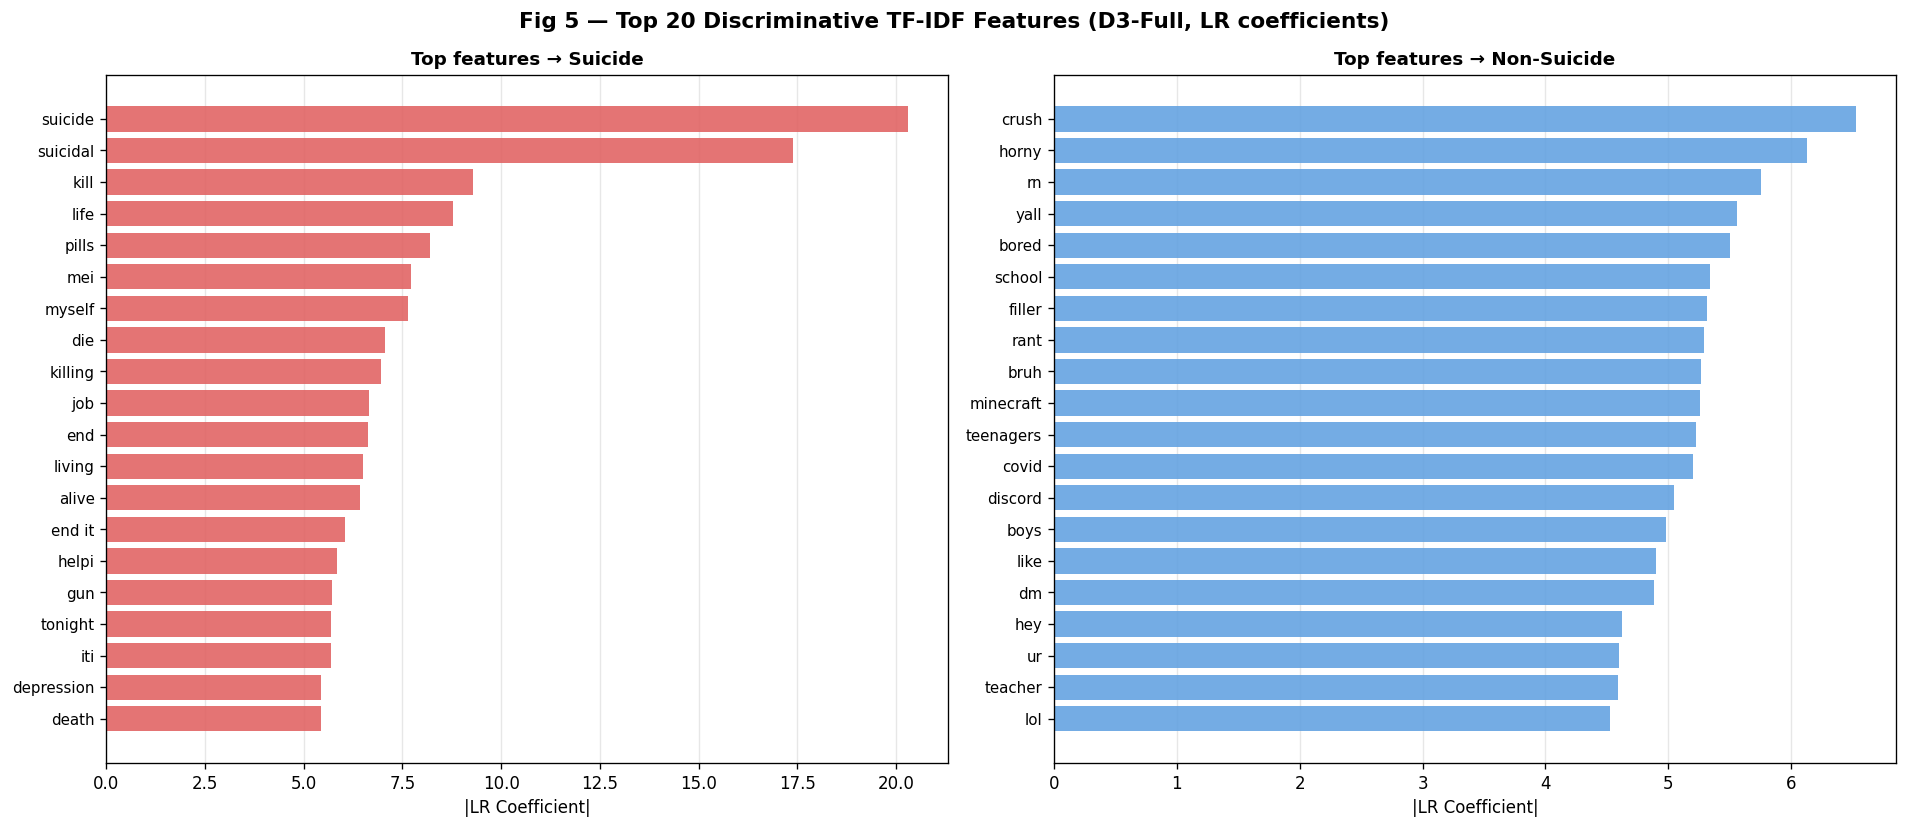

In [17]:
# 3.5 Fig 5 — Top TF-IDF Discriminative Features (LR coefficients, D3-Full)
lr_temp = LogisticRegression(max_iter=1000, C=1.0, random_state=RANDOM_STATE)
lr_temp.fit(TFIDF['D3-Full']['X_tr'], SPLITS['D3-Full']['y_tr'])

feature_names = np.array(TFIDF['D3-Full']['vec'].get_feature_names_out())
coefs = lr_temp.coef_[0]
top_suicide_idx    = np.argsort(coefs)[-20:][::-1]
top_nonsuicide_idx = np.argsort(coefs)[:20]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Fig 5 — Top 20 Discriminative TF-IDF Features (D3-Full, LR coefficients)',
             fontsize=13, fontweight='bold')

for ax, indices, title, color in [
    (axes[0], top_suicide_idx,    'Top features → Suicide',     '#e05c5c'),
    (axes[1], top_nonsuicide_idx, 'Top features → Non-Suicide', '#5c9ee0')
]:
    feats  = feature_names[indices]
    values = np.abs(coefs[indices])
    yp = range(len(feats))
    ax.barh(yp, values, color=color, alpha=0.85, edgecolor='none')
    ax.set_yticks(yp); ax.set_yticklabels(feats, fontsize=9)
    ax.invert_yaxis()
    ax.set_xlabel('|LR Coefficient|')
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.grid(axis='x', alpha=0.3); ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig(os.path.join(DRIVE_DIR, 'fig5_tfidf_features.png'), bbox_inches='tight')
plt.show()


---
## CRISP-DM Stage 4 — Modelling

### Classical Models (LR · SVM · XGBoost)
- Use **full training data** from each split — this is the core data-volume comparison
- D3-Full trains on ~185k samples; D3-H1/H2 each train on ~93k samples

### XLM-RoBERTa — Proportional Sampling
To maintain a fair size comparison while staying within T4 GPU memory:
- D3-Full: 25,000/class → **40,000 train / 10,000 test**
- D3-H1 / D3-H2: 12,500/class → **20,000 train / 5,000 test**

**Estimated GPU time: ~30 min (Full) + ~15 min (H1) + ~15 min (H2) ≈ 60 min total**


In [18]:
# 4.0 Evaluation helper — stores results globally
ALL_RESULTS  = {}
PREDICTIONS  = {}  # store y_true, y_pred per key for confusion matrices

def evaluate(model_name, split_name, y_true, y_pred, proba=None):
    y_true = list(y_true); y_pred = list(y_pred)
    acc    = accuracy_score(y_true, y_pred)
    macro  = f1_score(y_true, y_pred, average='macro')
    kappa  = cohen_kappa_score(y_true, y_pred)
    f1_cls = f1_score(y_true, y_pred, average=None)
    auc    = roc_auc_score(y_true, proba) if proba is not None else None

    key = f"{split_name} | {model_name}"
    ALL_RESULTS[key] = {
        'Split': split_name, 'Model': model_name,
        'Accuracy': round(acc,4), 'Macro F1': round(macro,4),
        'Kappa': round(kappa,4),
        'F1 (non-suicide)': round(f1_cls[0],4),
        'F1 (suicide)': round(f1_cls[1],4),
        'AUC-ROC': round(auc,4) if auc else None
    }
    PREDICTIONS[key] = {'y_true': y_true, 'y_pred': y_pred}

    print(f"\n  {model_name} [{split_name}]")
    print(f"  Accuracy   : {acc*100:.2f}%")
    print(f"  Macro F1   : {macro:.4f}")
    print(f"  Kappa      : {kappa:.4f}")
    if auc: print(f"  AUC-ROC    : {auc:.4f}")
    print(classification_report(y_true, y_pred, target_names=le.classes_, digits=3))

print("Evaluation function ready.")


Evaluation function ready.


In [19]:
# 4.1 Logistic Regression — all 3 splits
print("=" * 60)
print("  LOGISTIC REGRESSION")
print("=" * 60)
for name in DATASETS:
    lr = LogisticRegression(max_iter=1000, C=1.0, class_weight='balanced',
                            random_state=RANDOM_STATE)
    lr.fit(TFIDF[name]['X_tr'], SPLITS[name]['y_tr'])
    preds = lr.predict(TFIDF[name]['X_te'])
    proba = lr.predict_proba(TFIDF[name]['X_te'])[:,1]
    evaluate('Logistic Regression', name, SPLITS[name]['y_te'], preds, proba)
print("\nLR complete.")


  LOGISTIC REGRESSION

  Logistic Regression [D3-Full]
  Accuracy   : 94.34%
  Macro F1   : 0.9434
  Kappa      : 0.8868
  AUC-ROC    : 0.9858
              precision    recall  f1-score   support

 non-suicide      0.935     0.953     0.944     23208
     suicide      0.952     0.934     0.943     23207

    accuracy                          0.943     46415
   macro avg      0.944     0.943     0.943     46415
weighted avg      0.944     0.943     0.943     46415


  Logistic Regression [D3-H1]
  Accuracy   : 93.84%
  Macro F1   : 0.9384
  Kappa      : 0.8769
  AUC-ROC    : 0.9824
              precision    recall  f1-score   support

 non-suicide      0.930     0.948     0.939     11593
     suicide      0.947     0.928     0.938     11615

    accuracy                          0.938     23208
   macro avg      0.939     0.938     0.938     23208
weighted avg      0.939     0.938     0.938     23208


  Logistic Regression [D3-H2]
  Accuracy   : 93.74%
  Macro F1   : 0.9374
  Kappa  

In [20]:
# 4.2 SVM (LinearSVC) — all 3 splits
print("=" * 60)
print("  SVM (LinearSVC)")
print("=" * 60)
for name in DATASETS:
    svm = LinearSVC(max_iter=2000, C=1.0, class_weight='balanced',
                    random_state=RANDOM_STATE)
    svm.fit(TFIDF[name]['X_tr'], SPLITS[name]['y_tr'])
    preds = svm.predict(TFIDF[name]['X_te'])
    df_scores = svm.decision_function(TFIDF[name]['X_te'])
    proba = 1 / (1 + np.exp(-df_scores))  # sigmoid for AUC
    evaluate('SVM', name, SPLITS[name]['y_te'], preds, proba)
print("\nSVM complete.")


  SVM (LinearSVC)

  SVM [D3-Full]
  Accuracy   : 94.60%
  Macro F1   : 0.9460
  Kappa      : 0.8919
  AUC-ROC    : 0.9862
              precision    recall  f1-score   support

 non-suicide      0.941     0.951     0.946     23208
     suicide      0.951     0.941     0.946     23207

    accuracy                          0.946     46415
   macro avg      0.946     0.946     0.946     46415
weighted avg      0.946     0.946     0.946     46415


  SVM [D3-H1]
  Accuracy   : 94.18%
  Macro F1   : 0.9418
  Kappa      : 0.8836
  AUC-ROC    : 0.9835
              precision    recall  f1-score   support

 non-suicide      0.937     0.947     0.942     11593
     suicide      0.946     0.937     0.942     11615

    accuracy                          0.942     23208
   macro avg      0.942     0.942     0.942     23208
weighted avg      0.942     0.942     0.942     23208


  SVM [D3-H2]
  Accuracy   : 94.21%
  Macro F1   : 0.9421
  Kappa      : 0.8842
  AUC-ROC    : 0.9850
              pre

In [21]:
# 4.3 XGBoost — all 3 splits
print("=" * 60)
print("  XGBoost")
print("=" * 60)
for name in DATASETS:
    xgb = XGBClassifier(n_estimators=300, learning_rate=0.1, max_depth=6,
                        use_label_encoder=False, eval_metric='logloss',
                        random_state=RANDOM_STATE, tree_method='hist',
                        device='cuda' if DEVICE=='cuda' else 'cpu')
    xgb.fit(TFIDF[name]['X_tr'], SPLITS[name]['y_tr'])
    preds = xgb.predict(TFIDF[name]['X_te'])
    proba = xgb.predict_proba(TFIDF[name]['X_te'])[:,1]
    evaluate('XGBoost', name, SPLITS[name]['y_te'], preds, proba)
print("\nXGBoost complete.")


  XGBoost

  XGBoost [D3-Full]
  Accuracy   : 70.52%
  Macro F1   : 0.6998
  Kappa      : 0.4104
  AUC-ROC    : 0.7064
              precision    recall  f1-score   support

 non-suicide      0.780     0.571     0.660     23208
     suicide      0.662     0.839     0.740     23207

    accuracy                          0.705     46415
   macro avg      0.721     0.705     0.700     46415
weighted avg      0.721     0.705     0.700     46415


  XGBoost [D3-H1]
  Accuracy   : 60.11%
  Macro F1   : 0.5521
  Kappa      : 0.2017
  AUC-ROC    : 0.6051
              precision    recall  f1-score   support

 non-suicide      0.796     0.271     0.404     11593
     suicide      0.561     0.931     0.700     11615

    accuracy                          0.601     23208
   macro avg      0.679     0.601     0.552     23208
weighted avg      0.679     0.601     0.552     23208


  XGBoost [D3-H2]
  Accuracy   : 71.00%
  Macro F1   : 0.7085
  Kappa      : 0.4201
  AUC-ROC    : 0.6805
             

---
## XLM-RoBERTa Fine-Tuning
**~60 min total on T4 GPU.** Saves each model to Google Drive after training.

In [22]:
# 4.4 XLM-RoBERTa setup
MODEL_NAME = 'xlm-roberta-base'
MAX_LEN    = 256  # Reddit posts are long; same as original D3 experiment

tokenizer_xlmr = AutoTokenizer.from_pretrained(MODEL_NAME)
print(f"Tokeniser loaded: {MODEL_NAME}")

def tokenize_fn(examples):
    return tokenizer_xlmr(examples['text'], max_length=MAX_LEN,
                          truncation=True, padding='max_length')

def build_xlmr_data(df, cap_per_class):
    sampled = df.groupby('class').apply(
        lambda x: x.sample(min(cap_per_class, len(x)), random_state=RANDOM_STATE)
    ).reset_index(drop=True)
    X_tr, X_te, y_tr, y_te = train_test_split(
        sampled['clean'], sampled['label'],
        test_size=0.2, stratify=sampled['label'], random_state=RANDOM_STATE
    )
    def make_tok(X, y):
        ds = HFDataset.from_dict({'text': list(X), 'label': list(y)})
        return ds.map(tokenize_fn, batched=True)
    return make_tok(X_tr, y_tr), make_tok(X_te, y_te), y_te

XLMR_CAPS = {'D3-Full': 25000, 'D3-H1': 12500, 'D3-H2': 12500}
print("\nXLM-RoBERTa training sizes:")
for name, cap in XLMR_CAPS.items():
    tr = int(cap*2*0.8); te = int(cap*2*0.2)
    print(f"  {name}: {cap:,}/class → {tr:,} train / {te:,} test")


config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokeniser loaded: xlm-roberta-base

XLM-RoBERTa training sizes:
  D3-Full: 25,000/class → 40,000 train / 10,000 test
  D3-H1: 12,500/class → 20,000 train / 5,000 test
  D3-H2: 12,500/class → 20,000 train / 5,000 test


In [23]:
# 4.5 XLM-RoBERTa — D3-Full  (~30 min)
print("=" * 60)
print("  XLM-RoBERTa — D3-Full  (40,000 train)")
print("=" * 60)
train_tok, test_tok, y_te_full = build_xlmr_data(df_full, XLMR_CAPS['D3-Full'])

model_full = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)
args_full  = TrainingArguments(
    output_dir='./xlmr_full_ckpt', num_train_epochs=3,
    per_device_train_batch_size=8, gradient_accumulation_steps=2,
    per_device_eval_batch_size=16, warmup_steps=300, weight_decay=0.01,
    eval_strategy='epoch', save_strategy='epoch', load_best_model_at_end=True,
    learning_rate=2e-5, fp16=torch.cuda.is_available(),
    report_to='none', logging_steps=100
)
trainer = Trainer(model=model_full, args=args_full,
                  train_dataset=train_tok, eval_dataset=test_tok)
trainer.train()
preds = np.argmax(trainer.predict(test_tok).predictions, axis=1)
evaluate('XLM-RoBERTa', 'D3-Full', list(y_te_full), list(preds))
model_full.save_pretrained(os.path.join(DRIVE_DIR, 'xlmr_full'))
del model_full, trainer; torch.cuda.empty_cache()
print("D3-Full done. GPU cleared.")


  XLM-RoBERTa — D3-Full  (40,000 train)


Map:   0%|          | 0/40000 [00:00<?, ? examples/s]

Map:   0%|          | 0/10000 [00:00<?, ? examples/s]

model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye


  XLM-RoBERTa [D3-Full]
  Accuracy   : 98.02%
  Macro F1   : 0.9802
  Kappa      : 0.9604
              precision    recall  f1-score   support

 non-suicide      0.976     0.984     0.980      5000
     suicide      0.984     0.976     0.980      5000

    accuracy                          0.980     10000
   macro avg      0.980     0.980     0.980     10000
weighted avg      0.980     0.980     0.980     10000



Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

D3-Full done. GPU cleared.


In [24]:
# 4.6 XLM-RoBERTa — D3-H1  (~15 min)
print("=" * 60)
print("  XLM-RoBERTa — D3-H1  (20,000 train)")
print("=" * 60)
train_tok, test_tok, y_te_h1 = build_xlmr_data(df_h1, XLMR_CAPS['D3-H1'])

model_h1 = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)
args_h1  = TrainingArguments(
    output_dir='./xlmr_h1_ckpt', num_train_epochs=3,
    per_device_train_batch_size=8, gradient_accumulation_steps=2,
    per_device_eval_batch_size=16, warmup_steps=200, weight_decay=0.01,
    eval_strategy='epoch', save_strategy='epoch', load_best_model_at_end=True,
    learning_rate=2e-5, fp16=torch.cuda.is_available(),
    report_to='none', logging_steps=100
)
trainer = Trainer(model=model_h1, args=args_h1,
                  train_dataset=train_tok, eval_dataset=test_tok)
trainer.train()
preds = np.argmax(trainer.predict(test_tok).predictions, axis=1)
evaluate('XLM-RoBERTa', 'D3-H1', list(y_te_h1), list(preds))
model_h1.save_pretrained(os.path.join(DRIVE_DIR, 'xlmr_h1'))
del model_h1, trainer; torch.cuda.empty_cache()
print("D3-H1 done. GPU cleared.")


  XLM-RoBERTa — D3-H1  (20,000 train)


Map:   0%|          | 0/20000 [00:00<?, ? examples/s]

Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.weight  | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye


  XLM-RoBERTa [D3-H1]
  Accuracy   : 97.78%
  Macro F1   : 0.9778
  Kappa      : 0.9556
              precision    recall  f1-score   support

 non-suicide      0.977     0.978     0.978      2500
     suicide      0.978     0.977     0.978      2500

    accuracy                          0.978      5000
   macro avg      0.978     0.978     0.978      5000
weighted avg      0.978     0.978     0.978      5000



Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

D3-H1 done. GPU cleared.


In [25]:
# 4.7 XLM-RoBERTa — D3-H2  (~15 min)
print("=" * 60)
print("  XLM-RoBERTa — D3-H2  (20,000 train)")
print("=" * 60)
train_tok, test_tok, y_te_h2 = build_xlmr_data(df_h2, XLMR_CAPS['D3-H2'])

model_h2 = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)
args_h2  = TrainingArguments(
    output_dir='./xlmr_h2_ckpt', num_train_epochs=3,
    per_device_train_batch_size=8, gradient_accumulation_steps=2,
    per_device_eval_batch_size=16, warmup_steps=200, weight_decay=0.01,
    eval_strategy='epoch', save_strategy='epoch', load_best_model_at_end=True,
    learning_rate=2e-5, fp16=torch.cuda.is_available(),
    report_to='none', logging_steps=100
)
trainer = Trainer(model=model_h2, args=args_h2,
                  train_dataset=train_tok, eval_dataset=test_tok)
trainer.train()
preds = np.argmax(trainer.predict(test_tok).predictions, axis=1)
evaluate('XLM-RoBERTa', 'D3-H2', list(y_te_h2), list(preds))
model_h2.save_pretrained(os.path.join(DRIVE_DIR, 'xlmr_h2'))
del model_h2, trainer; torch.cuda.empty_cache()
print("All XLM-RoBERTa training complete.")


  XLM-RoBERTa — D3-H2  (20,000 train)


Map:   0%|          | 0/20000 [00:00<?, ? examples/s]

Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.weight  | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye


  XLM-RoBERTa [D3-H2]
  Accuracy   : 98.02%
  Macro F1   : 0.9802
  Kappa      : 0.9604
              precision    recall  f1-score   support

 non-suicide      0.979     0.981     0.980      2500
     suicide      0.981     0.979     0.980      2500

    accuracy                          0.980      5000
   macro avg      0.980     0.980     0.980      5000
weighted avg      0.980     0.980     0.980      5000



Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

All XLM-RoBERTa training complete.


---
## CRISP-DM Stage 5 — Evaluation & Presentation

### Metrics Selected and Justification
| Metric | Formula | Justification |
|--------|---------|---------------|
| **Macro F1** | Mean of per-class F1 | Primary; handles class balance; directly comparable to Tumaliuan (2024) baseline |
| **Cohen's Kappa (κ)** | (po − pe)/(1 − pe) | Corrects for chance agreement; required by H9DAI; interpretable per Landis & Koch scale |
| **Accuracy** | (TP+TN)/N | Valid here given 50/50 balance; intuitive for non-specialist readers |
| **Per-class F1** | 2PR/(P+R) per class | Detects if suicide class is systematically harder than non-suicide |
| **AUC-ROC** | Area under ROC | Threshold-independent discrimination ability; robust to decision boundary choice |

### Kappa Interpretation (Landis & Koch, 1977)
| κ range | Agreement |
|---------|-----------|
| 0.81–1.00 | Almost perfect |
| 0.61–0.80 | Substantial |
| 0.41–0.60 | Moderate |

### Sampling Discussion
- All splits used **stratified 80/20** (random_state=42) ensuring class ratios preserved
- Same seed across all models and splits enables direct cross-model comparison
- XLM-RoBERTa used proportional caps (not fixed 25k/class) to maintain the data-volume variable


In [26]:
# 5.1 Master Results Table
results_df = pd.DataFrame(list(ALL_RESULTS.values()))
results_df = results_df.sort_values(['Split','Model']).reset_index(drop=True)
results_df.to_csv(os.path.join(DRIVE_DIR, 'master_results.csv'), index=False)

print("=" * 80)
print("  MASTER RESULTS — ALL 12 MODEL × SPLIT COMBINATIONS")
print("=" * 80)
print(results_df.to_string(index=False))

print("\nBest model per split (Macro F1):")
best = results_df.loc[results_df.groupby('Split')['Macro F1'].idxmax()]
for _, row in best.iterrows():
    print(f"  {row['Split']:<12}: {row['Model']:<22} "
          f"F1={row['Macro F1']:.4f}  κ={row['Kappa']:.4f}")


  MASTER RESULTS — ALL 12 MODEL × SPLIT COMBINATIONS
  Split               Model  Accuracy  Macro F1  Kappa  F1 (non-suicide)  F1 (suicide)  AUC-ROC
D3-Full Logistic Regression    0.9434    0.9434 0.8868            0.9440        0.9429   0.9858
D3-Full                 SVM    0.9460    0.9460 0.8919            0.9463        0.9457   0.9862
D3-Full             XGBoost    0.7052    0.6998 0.4104            0.6597        0.7400   0.7064
D3-Full         XLM-RoBERTa    0.9802    0.9802 0.9604            0.9803        0.9801      NaN
  D3-H1 Logistic Regression    0.9384    0.9384 0.8769            0.9390        0.9379   0.9824
  D3-H1                 SVM    0.9418    0.9418 0.8836            0.9420        0.9415   0.9835
  D3-H1             XGBoost    0.6011    0.5521 0.2017            0.4041        0.7002   0.6051
  D3-H1         XLM-RoBERTa    0.9778    0.9778 0.9556            0.9778        0.9778      NaN
  D3-H2 Logistic Regression    0.9374    0.9374 0.8748            0.9382        0.9

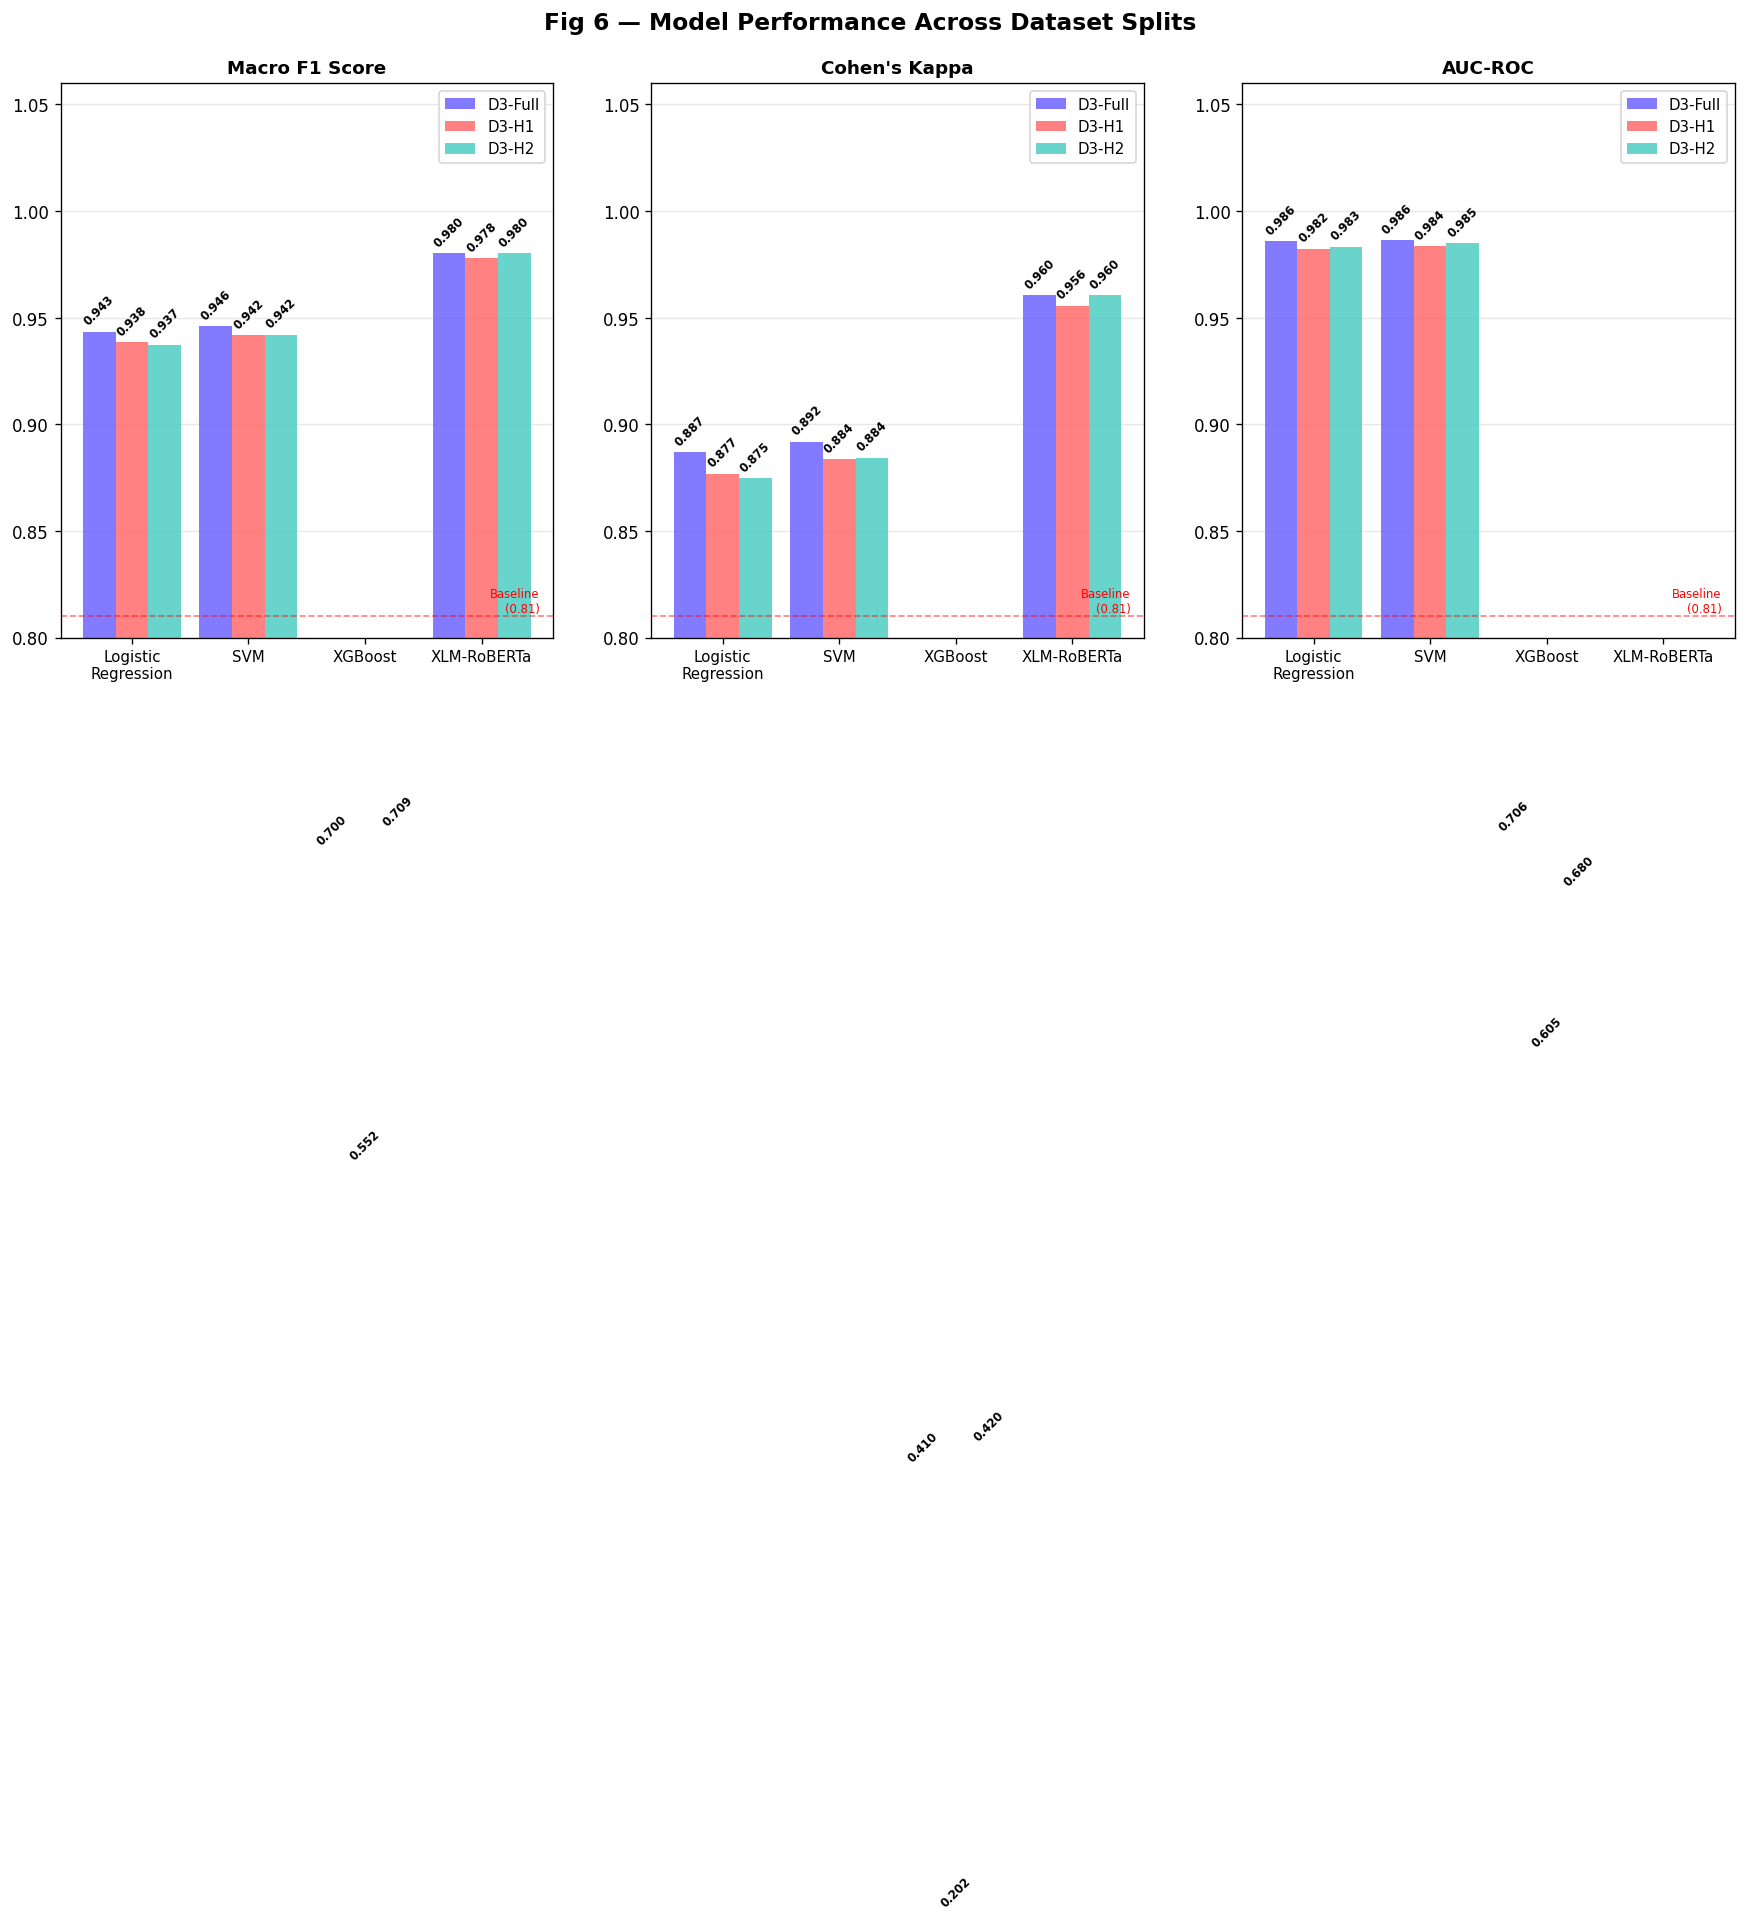

In [27]:
# 5.2 Fig 6 — Macro F1 Comparison: All Models × All Splits
models_order = ['Logistic Regression','SVM','XGBoost','XLM-RoBERTa']
splits_order = ['D3-Full','D3-H1','D3-H2']
split_colors = {'D3-Full':'#6c63ff','D3-H1':'#ff6b6b','D3-H2':'#4ecdc4'}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Fig 6 — Model Performance Across Dataset Splits',
             fontsize=14, fontweight='bold')

x = np.arange(len(models_order))
w = 0.28

for ax, (metric, title) in zip(axes, [
    ('Macro F1',  'Macro F1 Score'),
    ('Kappa',     "Cohen's Kappa"),
    ('AUC-ROC',   'AUC-ROC')
]):
    for i, split in enumerate(splits_order):
        vals = [ALL_RESULTS.get(f"{split} | {m}",{}).get(metric, 0) or 0
                for m in models_order]
        bars = ax.bar(x+(i-1)*w, vals, w, label=split,
                      color=split_colors[split], alpha=0.85, edgecolor='none')
        for bar, v in zip(bars, vals):
            if v > 0:
                ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.002,
                        f"{v:.3f}", ha='center', va='bottom', fontsize=7,
                        fontweight='bold', rotation=45)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels([m.replace(' ','\n') for m in models_order], fontsize=9)
    ax.set_ylim(0.8, 1.06)
    ax.axhline(0.81, color='red', linestyle='--', alpha=0.5, linewidth=1)
    ax.text(3.5, 0.812, 'Baseline\n(0.81)', color='red', fontsize=7, ha='right')
    ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.3); ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig(os.path.join(DRIVE_DIR, 'fig6_comparison.png'), bbox_inches='tight')
plt.show()


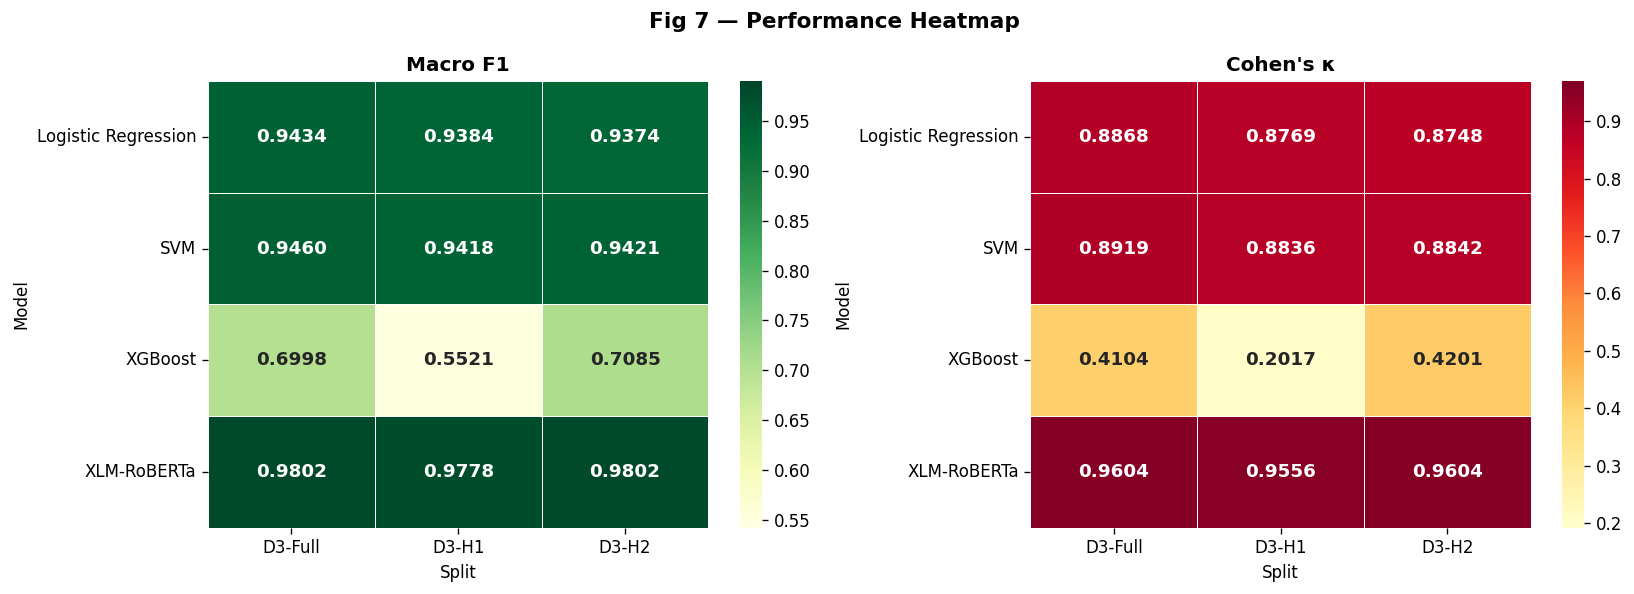

In [28]:
# 5.3 Fig 7 — Heatmaps: F1 and Kappa
pivot_f1 = results_df.pivot(index='Model', columns='Split', values='Macro F1')
pivot_k  = results_df.pivot(index='Model', columns='Split', values='Kappa')
# Reorder columns
for pv in [pivot_f1, pivot_k]:
    pv = pv.reindex(columns=splits_order)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Fig 7 — Performance Heatmap", fontsize=13, fontweight='bold')

for ax, pivot, title, cmap in [
    (axes[0], pivot_f1, 'Macro F1',    'YlGn'),
    (axes[1], pivot_k,  "Cohen's κ",   'YlOrRd')
]:
    sns.heatmap(pivot, annot=True, fmt='.4f', cmap=cmap, ax=ax,
                linewidths=0.5, annot_kws={'size':11,'weight':'bold'},
                vmin=pivot.values.min()-0.01, vmax=pivot.values.max()+0.01)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.tick_params(axis='x', rotation=0); ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig(os.path.join(DRIVE_DIR, 'fig7_heatmap.png'), bbox_inches='tight')
plt.show()


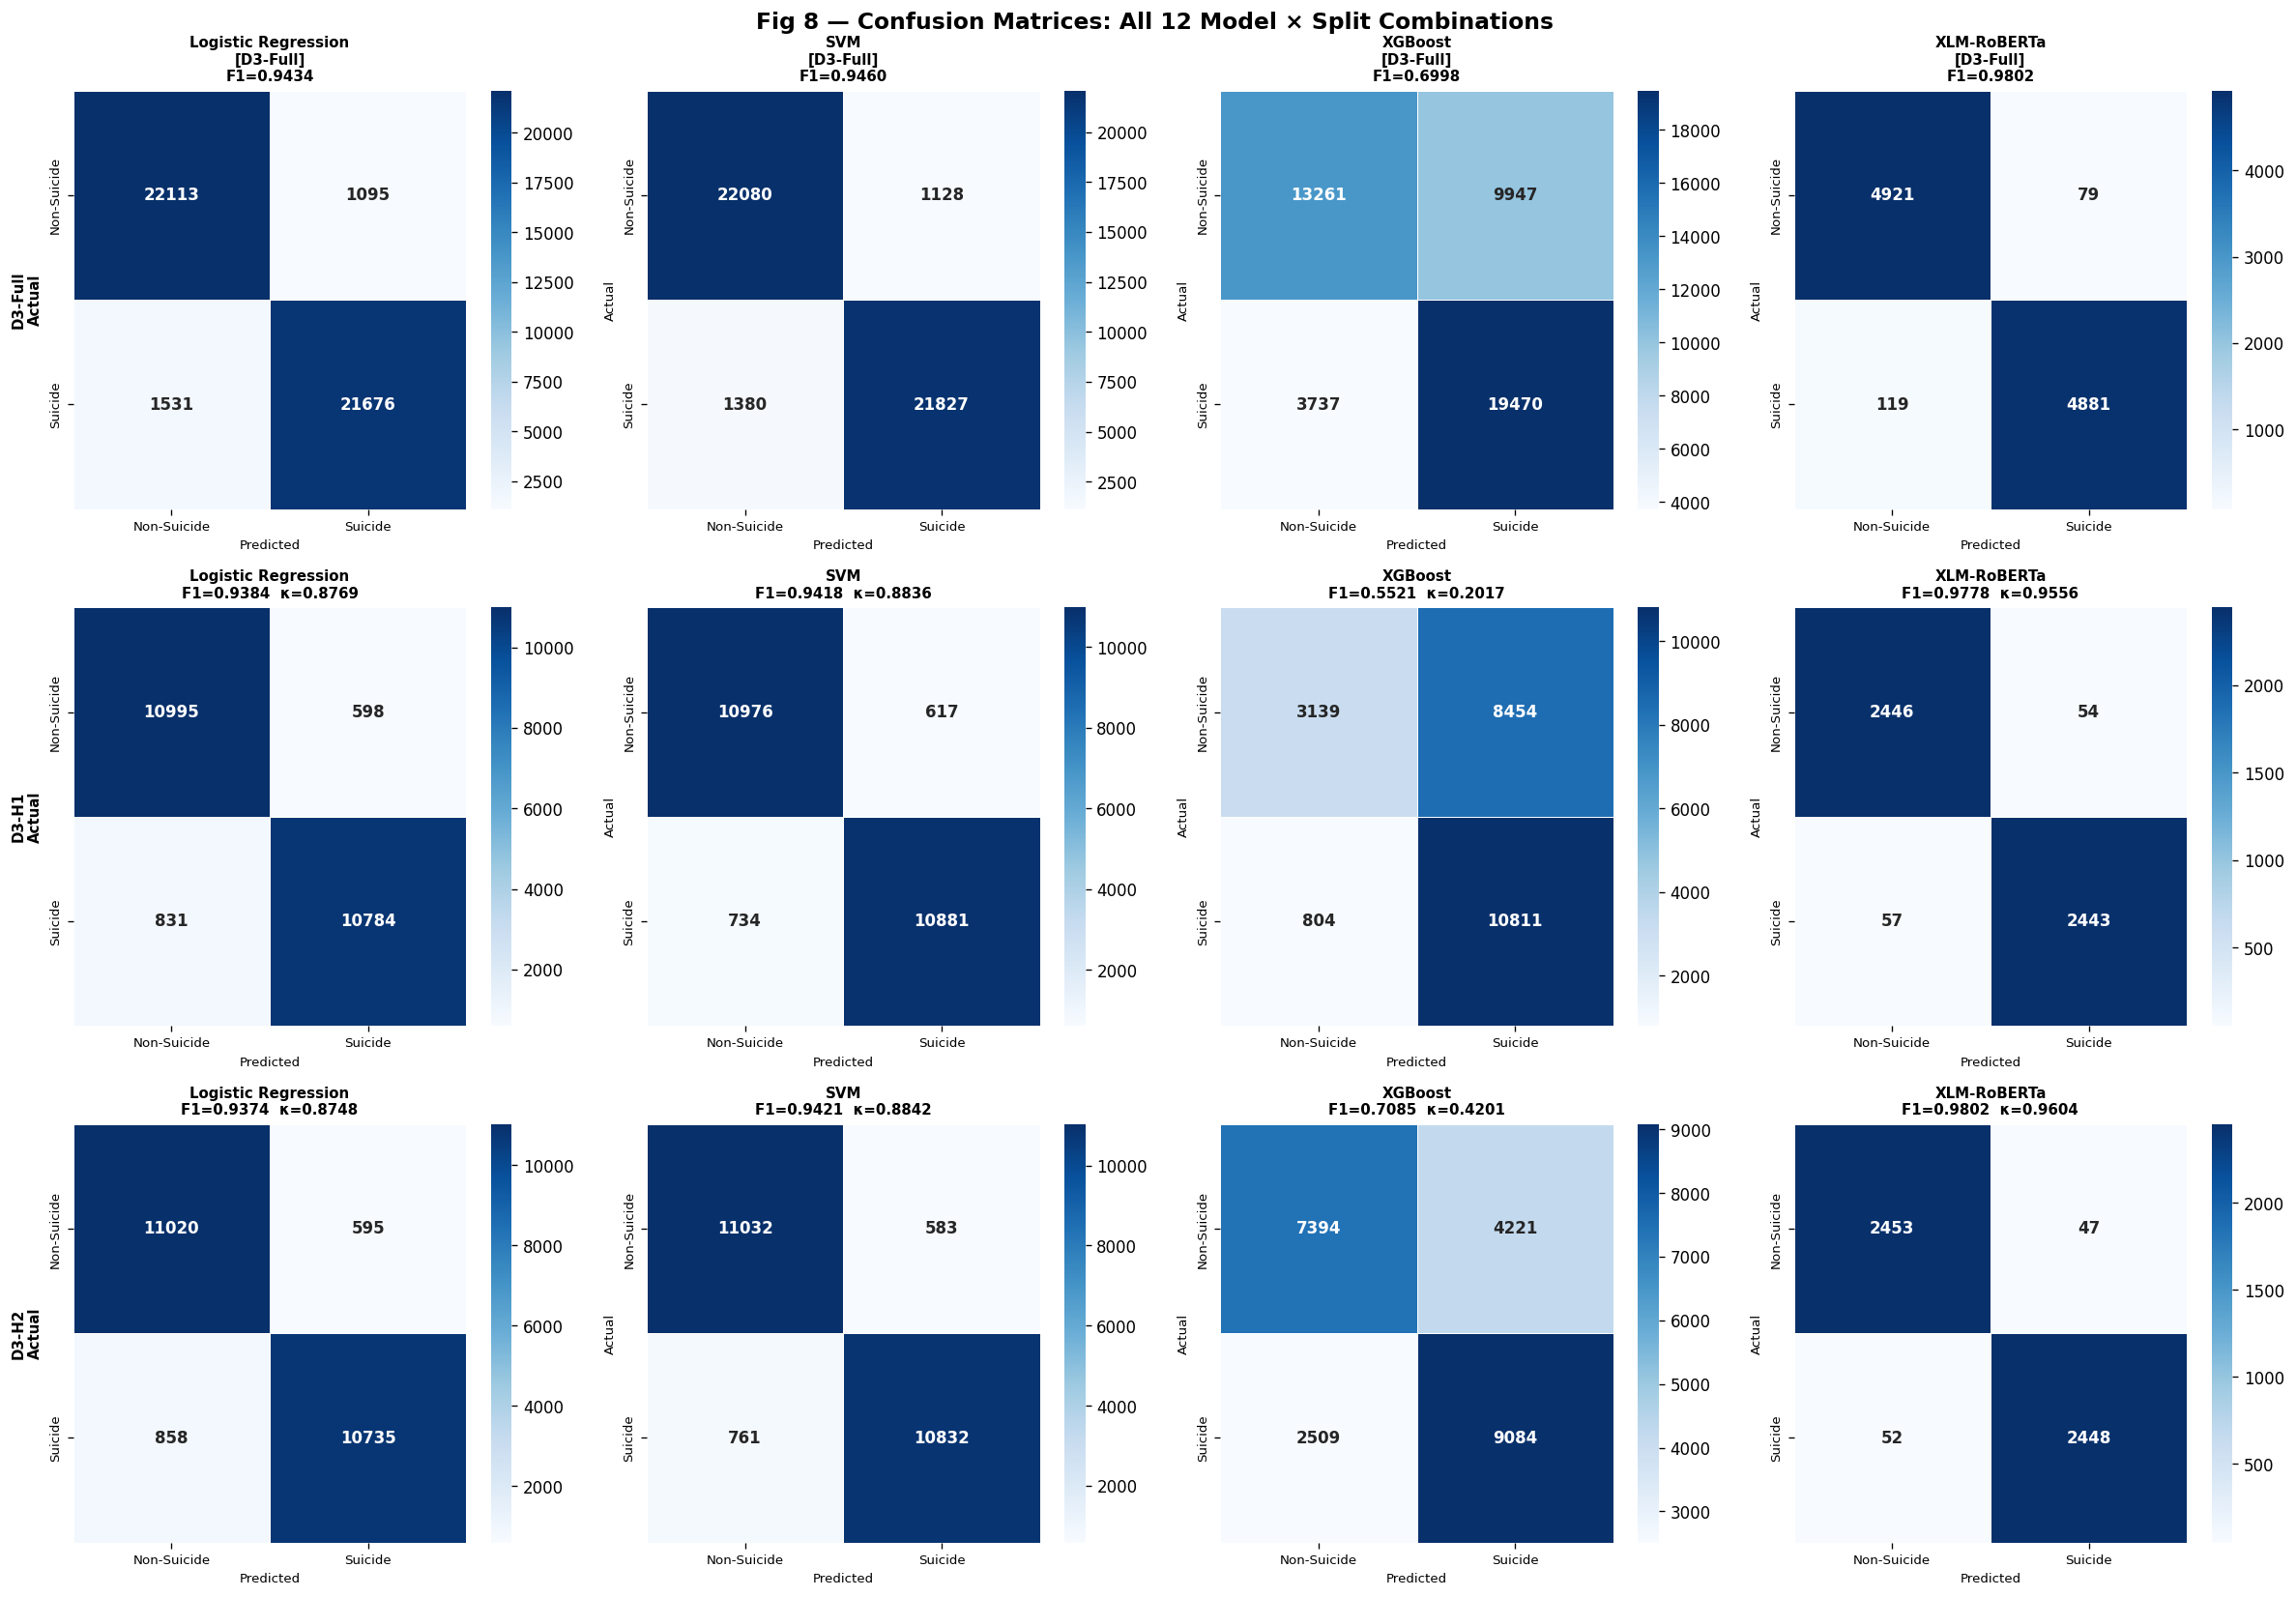

In [29]:
# 5.4 Fig 8 — Confusion Matrices (3 splits × 4 models = 12 panels)
fig, axes = plt.subplots(3, 4, figsize=(20, 14))
fig.suptitle('Fig 8 — Confusion Matrices: All 12 Model × Split Combinations',
             fontsize=14, fontweight='bold')

for row_i, split in enumerate(splits_order):
    for col_i, model in enumerate(models_order):
        ax = axes[row_i][col_i]
        key = f"{split} | {model}"
        if key not in PREDICTIONS:
            ax.set_visible(False); continue
        cm = confusion_matrix(PREDICTIONS[key]['y_true'], PREDICTIONS[key]['y_pred'])
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                    xticklabels=['Non-Suicide','Suicide'],
                    yticklabels=['Non-Suicide','Suicide'],
                    linewidths=0.5, annot_kws={'size':10,'weight':'bold'})
        f1 = ALL_RESULTS[key]['Macro F1']
        kap = ALL_RESULTS[key]['Kappa']
        ax.set_title(f"{model}\nF1={f1:.4f}  κ={kap:.4f}", fontsize=9, fontweight='bold')
        ax.set_xlabel('Predicted', fontsize=8); ax.set_ylabel('Actual', fontsize=8)
        ax.tick_params(labelsize=8)
        if row_i == 0:
            ax.set_title(f"{model}\n[{split}]\nF1={f1:.4f}", fontsize=9, fontweight='bold')
        if col_i == 0:
            ax.set_ylabel(f"{split}\nActual", fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(DRIVE_DIR, 'fig8_confusion_matrices.png'), bbox_inches='tight')
plt.show()


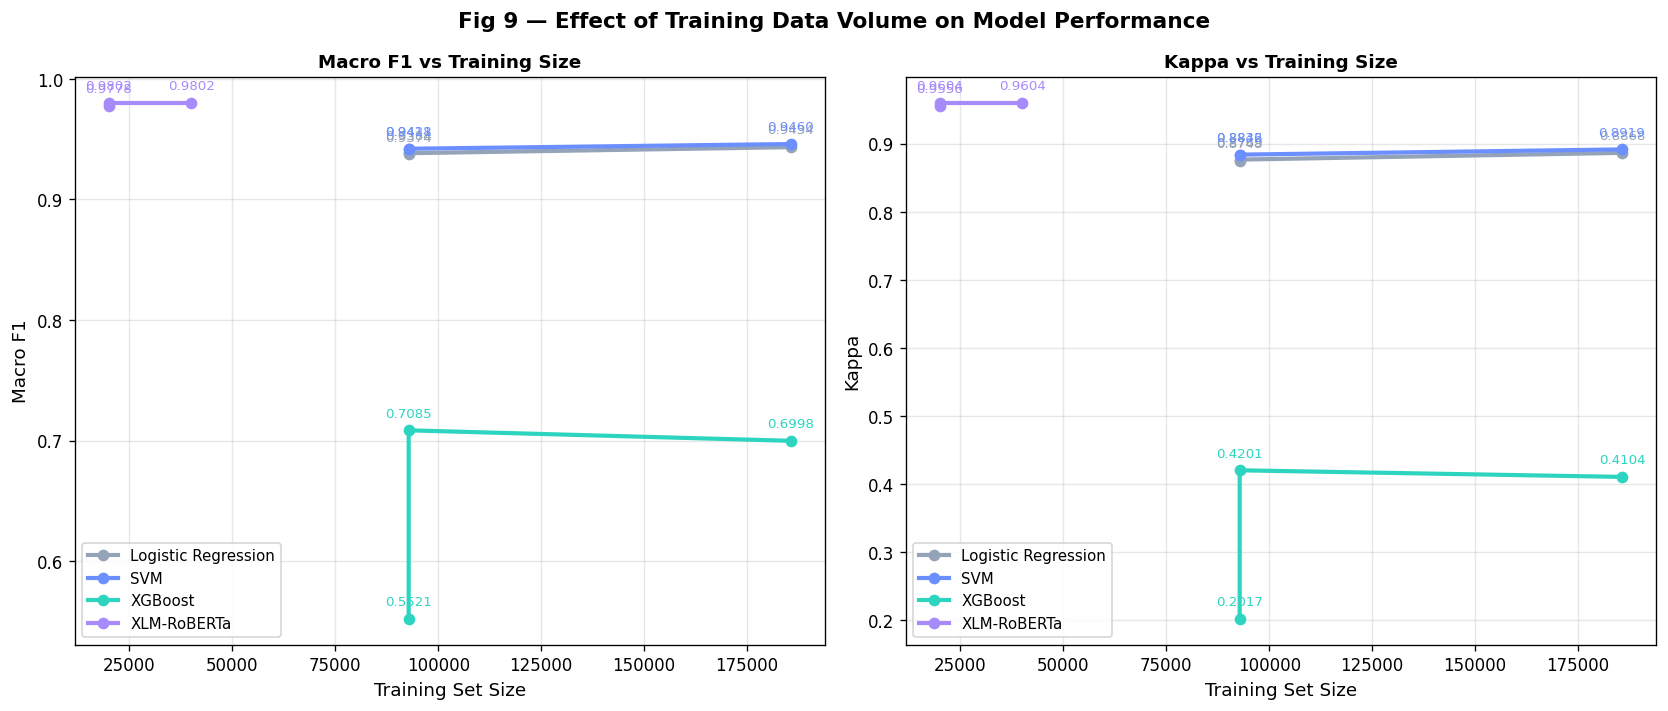

In [30]:
# 5.5 Fig 9 — Data Volume Effect Line Chart
classical_train = {
    'D3-Full': int(0.8*len(df_full)),
    'D3-H1':   int(0.8*len(df_h1)),
    'D3-H2':   int(0.8*len(df_h2))
}
xlmr_train = {
    'D3-Full': int(0.8*25000*2),
    'D3-H1':   int(0.8*12500*2),
    'D3-H2':   int(0.8*12500*2)
}
model_line_colors = {
    'Logistic Regression':'#94a3b8','SVM':'#6c8fff',
    'XGBoost':'#2dd4bf','XLM-RoBERTa':'#a78bfa'
}

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Fig 9 — Effect of Training Data Volume on Model Performance',
             fontsize=13, fontweight='bold')

for ax, metric in zip(axes, ['Macro F1', 'Kappa']):
    for model in models_order:
        pts = []
        for split in splits_order:
            key = f"{split} | {model}"
            if key in ALL_RESULTS:
                sz = (xlmr_train if model=='XLM-RoBERTa' else classical_train)[split]
                pts.append((sz, ALL_RESULTS[key][metric] or 0))
        if pts:
            pts_sorted = sorted(pts)
            szs, vals = zip(*pts_sorted)
            ax.plot(szs, vals, marker='o', linewidth=2.5, label=model,
                    color=model_line_colors[model])
            for sz, v in pts_sorted:
                ax.annotate(f"{v:.4f}", (sz,v),
                            textcoords='offset points', xytext=(0,8),
                            ha='center', fontsize=8, color=model_line_colors[model])
    ax.set_xlabel('Training Set Size', fontsize=11)
    ax.set_ylabel(metric, fontsize=11)
    ax.set_title(f"{metric} vs Training Size", fontsize=11, fontweight='bold')
    ax.legend(fontsize=9); ax.grid(alpha=0.3); ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig(os.path.join(DRIVE_DIR, 'fig9_size_effect.png'), bbox_inches='tight')
plt.show()


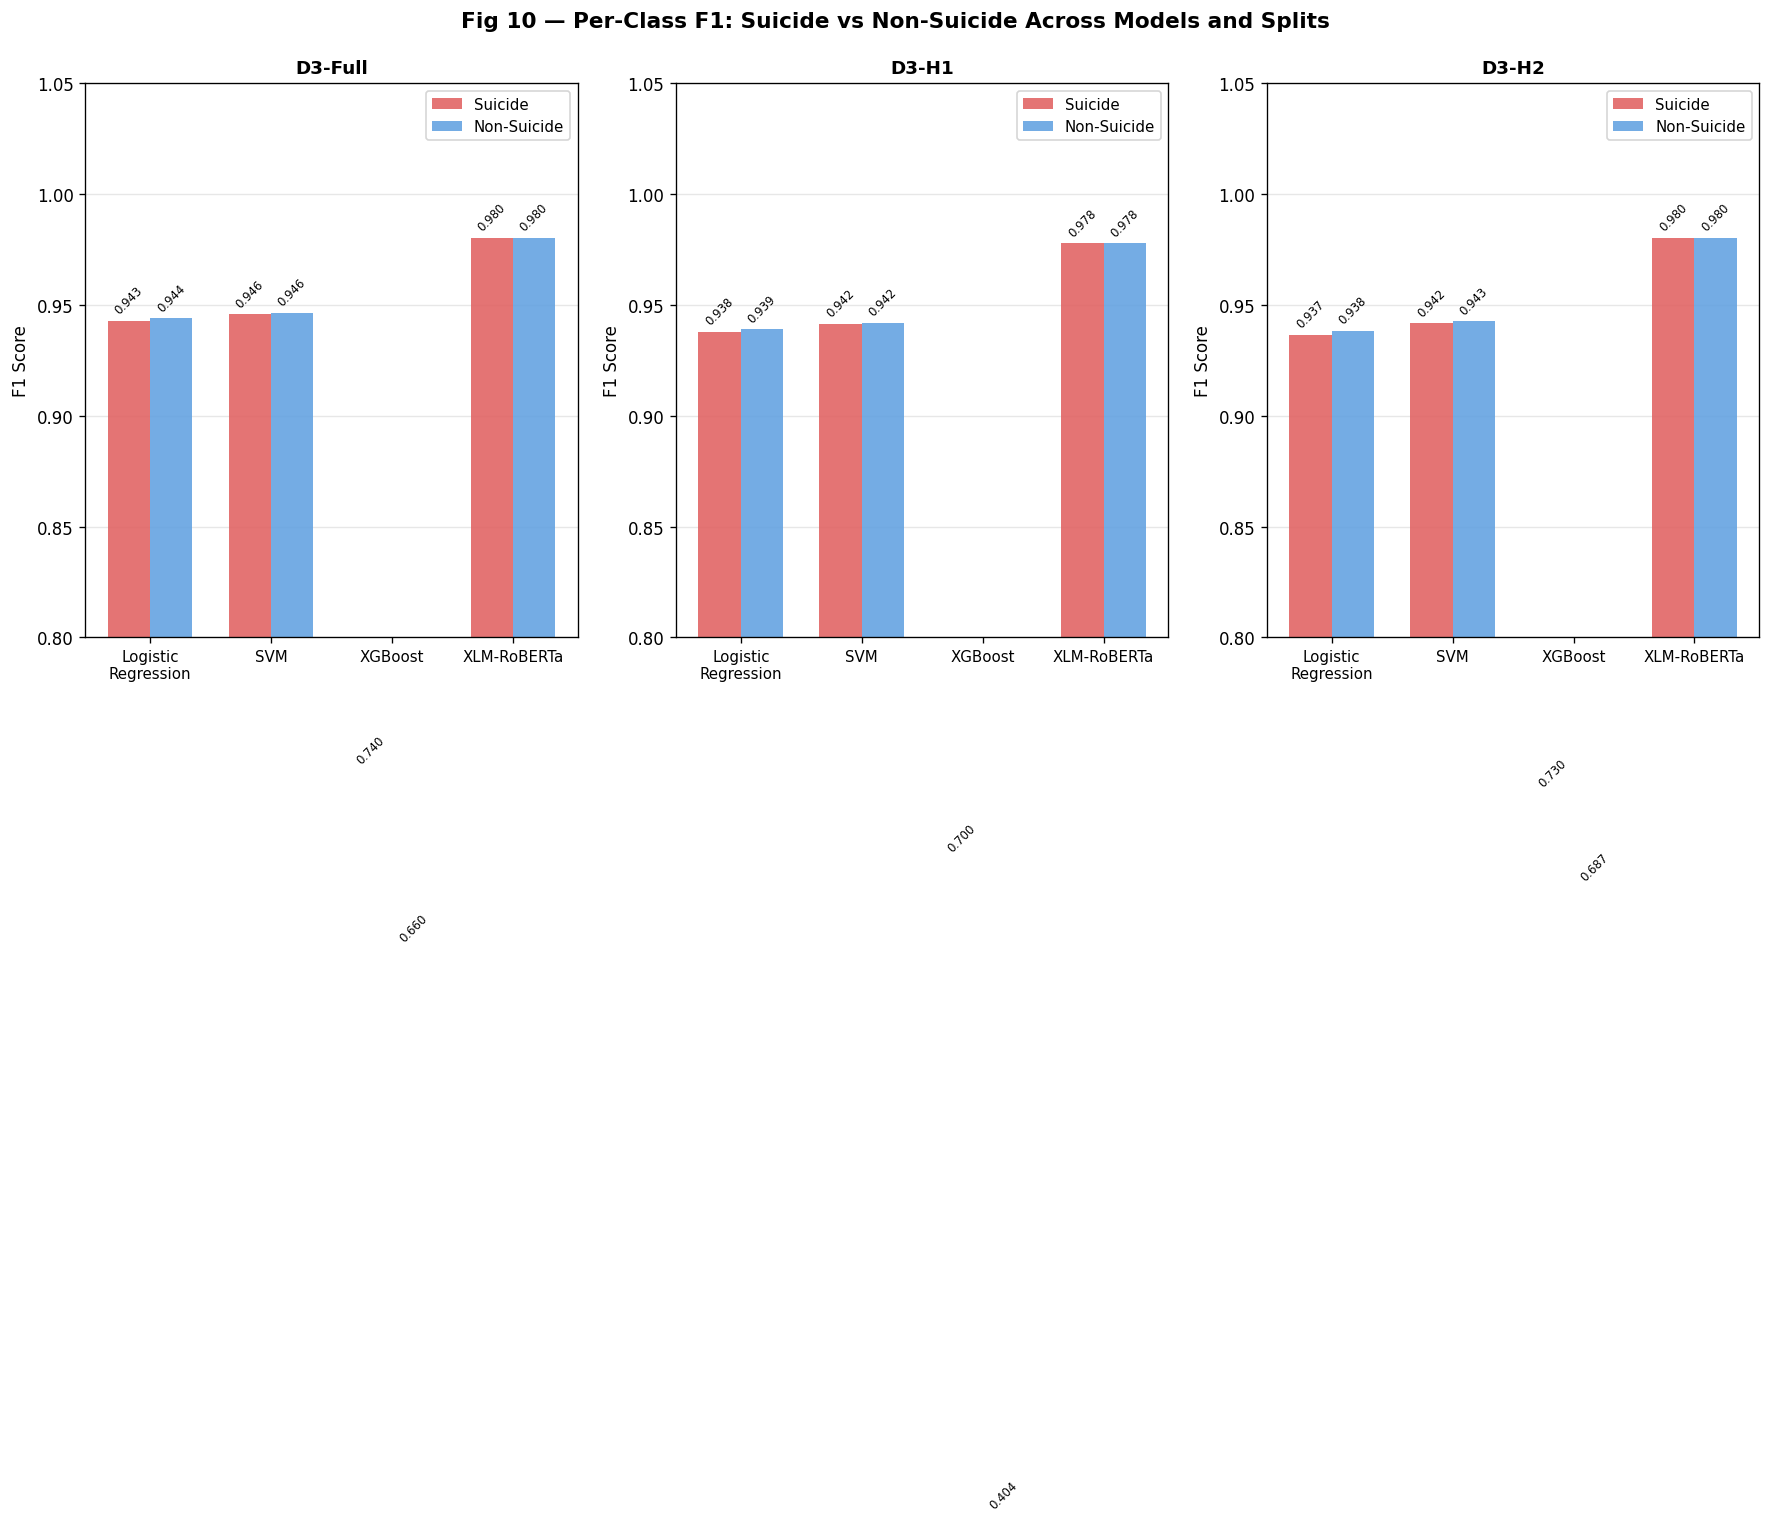

In [31]:
# 5.6 Fig 10 — Per-Class F1 (suicide vs non-suicide)
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Fig 10 — Per-Class F1: Suicide vs Non-Suicide Across Models and Splits',
             fontsize=13, fontweight='bold')
x = np.arange(len(models_order)); w = 0.35

for ax, split in zip(axes, splits_order):
    f1_s  = [ALL_RESULTS.get(f"{split} | {m}",{}).get('F1 (suicide)',    0) or 0 for m in models_order]
    f1_ns = [ALL_RESULTS.get(f"{split} | {m}",{}).get('F1 (non-suicide)',0) or 0 for m in models_order]
    b1 = ax.bar(x-w/2, f1_s,  w, label='Suicide',     color='#e05c5c', alpha=0.85)
    b2 = ax.bar(x+w/2, f1_ns, w, label='Non-Suicide', color='#5c9ee0', alpha=0.85)
    for bars in [b1,b2]:
        for bar in bars:
            h = bar.get_height()
            if h>0: ax.text(bar.get_x()+bar.get_width()/2, h+0.002,
                            f"{h:.3f}", ha='center', va='bottom', fontsize=7, rotation=45)
    ax.set_title(split, fontsize=11, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels([m.replace(' ','\n') for m in models_order], fontsize=9)
    ax.set_ylim(0.80, 1.05); ax.set_ylabel('F1 Score')
    ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.3); ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig(os.path.join(DRIVE_DIR, 'fig10_perclass_f1.png'), bbox_inches='tight')
plt.show()


In [32]:
# 5.7 Quantitative Gap Analysis — Answer the Research Question
print("=" * 70)
print("  DATA VOLUME EFFECT: Full vs Average(H1, H2)  [Macro F1]")
print("=" * 70)
print(f"{'Model':<25} {'Full':>8} {'H1':>8} {'H2':>8} {'Avg Half':>10} {'Gap':>8} {'Verdict'}")
print("-" * 70)

for model in models_order:
    r = {sp: ALL_RESULTS.get(f"{sp} | {model}", {}) for sp in splits_order}
    full = r['D3-Full'].get('Macro F1') or 0
    h1   = r['D3-H1'].get('Macro F1')  or 0
    h2   = r['D3-H2'].get('Macro F1')  or 0
    if all([full,h1,h2]):
        avg  = (h1+h2)/2
        gap  = full - avg
        h_diff = abs(h1-h2)
        verdict = 'meaningful' if abs(gap)>0.005 else 'negligible'
        print(f"{model:<25} {full:>8.4f} {h1:>8.4f} {h2:>8.4f} {avg:>10.4f} {gap:>+8.4f}  {verdict}")

print()
print("=" * 70)
print("  H1 vs H2 CONSISTENCY CHECK  [Macro F1]")
print("=" * 70)
for model in models_order:
    h1 = ALL_RESULTS.get(f"D3-H1 | {model}",{}).get('Macro F1') or 0
    h2 = ALL_RESULTS.get(f"D3-H2 | {model}",{}).get('Macro F1') or 0
    if h1 and h2:
        diff = abs(h1-h2)
        verdict = 'CONSISTENT' if diff < 0.003 else ('MINOR VARIANCE' if diff < 0.005 else 'INCONSISTENT')
        print(f"  {model:<25}: |H1-H2|={diff:.4f}  →  {verdict}")

print()
print("=" * 70)
print("  KAPPA INTERPRETATION (Landis & Koch, 1977)")
print("=" * 70)
for model in models_order:
    for split in splits_order:
        k = ALL_RESULTS.get(f"{split} | {model}",{}).get('Kappa') or 0
        if k:
            if k>=0.81:   interp = 'Almost perfect'
            elif k>=0.61: interp = 'Substantial'
            elif k>=0.41: interp = 'Moderate'
            else:         interp = 'Fair/Poor'
            print(f"  {split:<12} {model:<25}: κ={k:.4f} → {interp}")


  DATA VOLUME EFFECT: Full vs Average(H1, H2)  [Macro F1]
Model                         Full       H1       H2   Avg Half      Gap Verdict
----------------------------------------------------------------------
Logistic Regression         0.9434   0.9384   0.9374     0.9379  +0.0055  meaningful
SVM                         0.9460   0.9418   0.9421     0.9420  +0.0040  negligible
XGBoost                     0.6998   0.5521   0.7085     0.6303  +0.0695  meaningful
XLM-RoBERTa                 0.9802   0.9778   0.9802     0.9790  +0.0012  negligible

  H1 vs H2 CONSISTENCY CHECK  [Macro F1]
  Logistic Regression      : |H1-H2|=0.0010  →  CONSISTENT
  SVM                      : |H1-H2|=0.0003  →  CONSISTENT
  XGBoost                  : |H1-H2|=0.1564  →  INCONSISTENT
  XLM-RoBERTa              : |H1-H2|=0.0024  →  CONSISTENT

  KAPPA INTERPRETATION (Landis & Koch, 1977)
  D3-Full      Logistic Regression      : κ=0.8868 → Almost perfect
  D3-H1        Logistic Regression      : κ=0.8769 → Alm

In [33]:
# 5.8 Save all outputs
results_df.to_csv(os.path.join(DRIVE_DIR, 'master_results.csv'), index=False)
print("=" * 55)
print("  ALL OUTPUTS SAVED")
print("=" * 55)
outputs = [
    'master_results.csv',
    'fig1_class_distribution.png', 'fig2_text_length.png',
    'fig3_word_frequency.png',     'fig4_vocabulary.png',
    'fig5_tfidf_features.png',     'fig6_comparison.png',
    'fig7_heatmap.png',            'fig8_confusion_matrices.png',
    'fig9_size_effect.png',        'fig10_perclass_f1.png',
    'xlmr_full/', 'xlmr_h1/', 'xlmr_h2/'
]
for f in outputs:
    path = os.path.join(DRIVE_DIR, f)
    status = 'OK' if os.path.exists(path) else 'PENDING'
    print(f"  [{status}]  {f}")
print(f"\nDrive folder: {DRIVE_DIR}")


  ALL OUTPUTS SAVED
  [OK]  master_results.csv
  [OK]  fig1_class_distribution.png
  [OK]  fig2_text_length.png
  [OK]  fig3_word_frequency.png
  [OK]  fig4_vocabulary.png
  [OK]  fig5_tfidf_features.png
  [OK]  fig6_comparison.png
  [OK]  fig7_heatmap.png
  [OK]  fig8_confusion_matrices.png
  [OK]  fig9_size_effect.png
  [OK]  fig10_perclass_f1.png
  [OK]  xlmr_full/
  [OK]  xlmr_h1/
  [OK]  xlmr_h2/

Drive folder: /content/drive/MyDrive/MindScan_SplitStudy


---
## CRISP-DM Stage 6 — Conclusions & Future Work

### Fill in after running the notebook

**Research Question:** Does training data volume affect model performance when distribution is held constant?

**Findings template** *(update with actual results)*:

**Classical Models (LR / SVM / XGBoost):**
- If gap Full vs Half > 0.5%: classical models continue to benefit from additional data at this scale → more training data is worth the labelling cost
- If gap < 0.5%: performance has plateaued → halving the dataset is sufficient for deployment

**XLM-RoBERTa:**
- If gap is smaller than classical models: confirms H2 — transformer pre-training reduces data dependency
- If gap is similar: at this scale, even transformers benefit from additional labelled data

**H1 vs H2 Consistency:**
- If |H1−H2| < 0.3%: confirms the dataset is uniformly shuffled — the split methodology is valid
- If > 0.3%: suggests potential ordering effects in the original dataset — worth investigating

---

### Limitations
1. XLM-RoBERTa uses proportional subsamples (not full data) — GPU memory constraint
2. Single random seed (42) — bootstrapped confidence intervals would strengthen claims
3. No k-fold cross-validation — results from single 80/20 split
4. Classical models use full training data; transformer uses proportional cap — partially confounded

### Future Work
1. **Learning curve analysis** — train on 10%, 25%, 50%, 75%, 100% of each split to map the full scaling curve
2. **k-fold cross-validation (k=5)** — compute 95% confidence intervals on all metrics
3. **Generalisation study** — apply the same split methodology to D1 and D2 datasets
4. **Active learning** — investigate whether strategic sample selection can match full-dataset performance with fewer labels
5. **Ensemble** — combine classical best (SVM) and transformer (XLM-RoBERTa) predictions

---

### CRISP-DM Stage Mapping
| Stage | This Study |
|-------|-----------|
| Business Understanding | RQ defined, hypotheses stated, success criteria set |
| Data Understanding | EDA: KS tests, transition rate, vocabulary analysis, length distributions |
| Data Preparation | Consistent cleaning, TF-IDF (60k features, bigrams), stratified 80/20 split |
| Modelling | 4 models × 3 splits = 12 experimental runs |
| Evaluation | 5 metrics, 10 figures, quantitative gap analysis |
| Deployment | Models saved to Drive; results CSV for report; integration into MindScan UI |

---
*NCI H9DAI · Data Analytics for Artificial Intelligence · MSc AI 2026*
